# Data Preprocessing

## Network Intrusion Detection Using Machine Learning

This notebook performs data preprocessing on the CIC-IDS2017 network intrusion detection dataset.

The objective of preprocessing is to transform the raw dataset into a clean and machine-learning-ready format.

The preprocessing pipeline includes:

- Loading the raw dataset.
- Cleaning column names.
- Inspecting and correcting data types.
- Handling infinite and missing values.
- Removing duplicate observations.
- Cleaning and encoding the target variable.
- Identifying and removing non-informative features.
- Investigating and handling extreme values.
- Reducing highly correlated features where appropriate.
- Splitting the dataset into training and testing sets.
- Scaling numerical features without data leakage.
- Performing final data-quality validation.
- Saving the processed data for use in machine learning models.

The preprocessing decisions are based on the findings obtained during Exploratory Data Analysis.

## 1. Import Required Libraries

The following libraries are used for data manipulation, numerical analysis, visualization, preprocessing, feature selection, and train-test splitting.

In [8]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import VarianceThreshold

import warnings
warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

print("Libraries imported successfully!")

Libraries imported successfully!


## 2. Load the Raw Dataset

The original CIC-IDS2017 dataset is loaded from the `data` directory.

The raw dataset is kept unchanged. A separate working copy will be created so that the original data remains available for reference.

In [9]:
df = pd.read_csv("/Users/kasturi/Desktop/Network-Intrusion-Detection/data/CIC_IDS2017.csv")

print("Raw dataset loaded successfully!")
print("Shape:", df.shape)

Raw dataset loaded successfully!
Shape: (1233163, 79)


## 3. Create a Working Copy

A copy of the raw dataset is created for preprocessing.

The original `df` loaded from the CSV file will remain available as a reference, while `data` will be modified throughout the preprocessing pipeline.

In [10]:
data = df.copy()

print("Working copy created successfully!")
print("Working dataset shape:", data.shape)

Working copy created successfully!
Working dataset shape: (1233163, 79)


## 4. Inspect the Raw Dataset Before Cleaning

Before making any changes, the structure of the raw dataset is examined.

This provides a baseline for comparing the dataset before and after preprocessing.

In [11]:
print("Shape:", data.shape)

print("\nFirst 5 records:")
display(data.head())

print("\nDataset information:")
data.info()

Shape: (1233163, 79)

First 5 records:


,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,Bwd Packet Length Max,Bwd Packet Length Min,Bwd Packet Length Mean,Bwd Packet Length Std,Flow Bytes/s,Flow Packets/s,Flow IAT Mean,Flow IAT Std,Flow IAT Max,Flow IAT Min,Fwd IAT Total,Fwd IAT Mean,Fwd IAT Std,Fwd IAT Max,Fwd IAT Min,Bwd IAT Total,Bwd IAT Mean,Bwd IAT Std,Bwd IAT Max,Bwd IAT Min,Fwd PSH Flags,Bwd PSH Flags,Fwd URG Flags,Bwd URG Flags,Fwd Header Length,Bwd Header Length,Fwd Packets/s,Bwd Packets/s,Min Packet Length,Max Packet Length,Packet Length Mean,Packet Length Std,Packet Length Variance,FIN Flag Count,SYN Flag Count,RST Flag Count,PSH Flag Count,ACK Flag Count,URG Flag Count,CWE Flag Count,ECE Flag Count,Down/Up Ratio,Average Packet Size,Avg Fwd Segment Size,Avg Bwd Segment Size,Fwd Header Length.1,Fwd Avg Bytes/Bulk,Fwd Avg Packets/Bulk,Fwd Avg Bulk Rate,Bwd Avg Bytes/Bulk,Bwd Avg Packets/Bulk,Bwd Avg Bulk Rate,Subflow Fwd Packets,Subflow Fwd Bytes,Subflow Bwd Packets,Subflow Bwd Bytes,Init_Win_bytes_forward,Init_Win_bytes_backward,act_data_pkt_fwd,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,49188,4,2,0,12,0,6,6,6.0,0.0,0,0,0.0,0.0,3000000.0,5.000000e+05,4.0,0.0,4,4,4,4.0,0.0,4,4,0,0.0,0.0,0,0,0,0,0,0,40,0,5.000000e+05,0.0,6,6,6.0,0.0,0.0,0,0,0,0,1,1,0,0,0,9.0,6.0,0.0,40,0,0,0,0,0,0,2,12,0,0,329,-1,1,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
1,49188,1,2,0,12,0,6,6,6.0,0.0,0,0,0.0,0.0,12000000.0,2.000000e+06,1.0,0.0,1,1,1,1.0,0.0,1,1,0,0.0,0.0,0,0,0,0,0,0,40,0,2.000000e+06,0.0,6,6,6.0,0.0,0.0,0,0,0,0,1,1,0,0,0,9.0,6.0,0.0,40,0,0,0,0,0,0,2,12,0,0,329,-1,1,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
2,49188,1,2,0,12,0,6,6,6.0,0.0,0,0,0.0,0.0,12000000.0,2.000000e+06,1.0,0.0,1,1,1,1.0,0.0,1,1,0,0.0,0.0,0,0,0,0,0,0,40,0,2.000000e+06,0.0,6,6,6.0,0.0,0.0,0,0,0,0,1,1,0,0,0,9.0,6.0,0.0,40,0,0,0,0,0,0,2,12,0,0,329,-1,1,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
3,49188,1,2,0,12,0,6,6,6.0,0.0,0,0,0.0,0.0,12000000.0,2.000000e+06,1.0,0.0,1,1,1,1.0,0.0,1,1,0,0.0,0.0,0,0,0,0,0,0,40,0,2.000000e+06,0.0,6,6,6.0,0.0,0.0,0,0,0,0,1,1,0,0,0,9.0,6.0,0.0,40,0,0,0,0,0,0,2,12,0,0,329,-1,1,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
4,49486,3,2,0,12,0,6,6,6.0,0.0,0,0,0.0,0.0,4000000.0,6.666667e+05,3.0,0.0,3,3,3,3.0,0.0,3,3,0,0.0,0.0,0,0,0,0,0,0,40,0,6.666667e+05,0.0,6,6,6.0,0.0,0.0,0,0,0,0,1,1,0,0,0,9.0,6.0,0.0,40,0,0,0,0,0,0,2,12,0,0,245,-1,1,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN



Dataset information:
<class 'pandas.DataFrame'>
RangeIndex: 1233163 entries, 0 to 1233162
Data columns (total 79 columns):
 #   Column                        Non-Null Count    Dtype  
---  ------                        --------------    -----  
 0    Destination Port             1233163 non-null  int64  
 1    Flow Duration                1233163 non-null  int64  
 2    Total Fwd Packets            1233163 non-null  int64  
 3    Total Backward Packets       1233163 non-null  int64  
 4   Total Length of Fwd Packets   1233163 non-null  int64  
 5    Total Length of Bwd Packets  1233163 non-null  int64  
 6    Fwd Packet Length Max        1233163 non-null  int64  
 7    Fwd Packet Length Min        1233163 non-null  int64  
 8    Fwd Packet Length Mean       1233163 non-null  float64
 9    Fwd Packet Length Std        1233163 non-null  float64
 10  Bwd Packet Length Max         1233163 non-null  int64  
 11   Bwd Packet Length Min        1233163 non-null  int64  
 12   Bwd Packet Lengt

## 5. Clean Column Names

The raw CIC-IDS2017 dataset may contain leading or trailing whitespace in column names.

Whitespace is removed from the beginning and end of each column name to create consistent and easier-to-use feature names.

This operation changes only the column names and does not modify the underlying data values.

In [12]:
# Store original column names
original_columns = data.columns.tolist()

# Remove leading and trailing whitespace
data.columns = data.columns.str.strip()

print("Column names cleaned successfully!")

print("\nExample of cleaned columns:")
print(data.columns[:10].tolist())

Column names cleaned successfully!

Example of cleaned columns:
['Destination Port', 'Flow Duration', 'Total Fwd Packets', 'Total Backward Packets', 'Total Length of Fwd Packets', 'Total Length of Bwd Packets', 'Fwd Packet Length Max', 'Fwd Packet Length Min', 'Fwd Packet Length Mean', 'Fwd Packet Length Std']


## 6. Compare Column Names Before and After Cleaning

The original and cleaned column names are compared to verify that whitespace has been removed correctly.

In [13]:
column_comparison = pd.DataFrame({
    "Original": original_columns,
    "Cleaned": data.columns
})

column_comparison.head(20)

,Original,Cleaned
0,Destination Port,Destination Port
1,Flow Duration,Flow Duration
2,Total Fwd Packets,Total Fwd Packets
3,Total Backward Packets,Total Backward Packets
4,Total Length of Fwd Packets,Total Length of Fwd Packets
5,Total Length of Bwd Packets,Total Length of Bwd Packets
6,Fwd Packet Length Max,Fwd Packet Length Max
7,Fwd Packet Length Min,Fwd Packet Length Min
8,Fwd Packet Length Mean,Fwd Packet Length Mean
9,Fwd Packet Length Std,Fwd Packet Length Std


## 7. Identify the Target Variable

The target variable represents the network traffic class that the machine learning model will learn to predict.

After cleaning the column names, the target variable is expected to be named `Label`.

In [14]:
target_column = "Label"

if target_column in data.columns:
    print("Target column found:", target_column)
else:
    print("Target column not found.")
    print("Available columns containing 'Label':")
    print([col for col in data.columns if "label" in col.lower()])

Target column found: Label


## 8. Examine Target Classes Before Cleaning

The target classes are inspected before any target processing is performed.

This helps identify inconsistent formatting, unexpected labels, or missing target values.

In [15]:
print("Target classes:")
print(data[target_column].value_counts(dropna=False))

Target classes:
Label
BENIGN      944240
PortScan    158930
DDoS        128027
Bot           1966
Name: count, dtype: int64


## 9. Clean Target Labels

Whitespace is removed from target labels to ensure that visually identical classes are represented consistently.

For example, values such as `BENIGN` and ` BENIGN ` should represent the same class.

In [16]:
data[target_column] = data[target_column].astype("string").str.strip()

print("Target labels cleaned successfully!")

print("\nUnique target classes:")
print(data[target_column].unique())

Target labels cleaned successfully!

Unique target classes:
<StringArray>
['BENIGN', 'Bot', 'PortScan', 'DDoS']
Length: 4, dtype: string


## 10. Check Missing Values After Target Cleaning

Missing values are checked across all columns.

Missing target values require special attention because a machine learning model cannot learn a class label when the target value is unavailable.

In [17]:
missing_values = data.isnull().sum()

missing_values = missing_values[
    missing_values > 0
].sort_values(ascending=False)

if len(missing_values) > 0:
    display(missing_values)
else:
    print("No missing values found.")

Flow Bytes/s    111
dtype: int64

## 11. Check for Infinite Values

Network traffic datasets can contain positive or negative infinite values, particularly in rate-based features.

Infinite values are not valid inputs for most machine learning algorithms and therefore need to be identified and handled.

In [18]:
infinite_count = np.isinf(
    data.select_dtypes(include=np.number)
).sum().sum()

print("Total infinite values:", infinite_count)

Total infinite values: 1817


## 12. Replace Infinite Values with Missing Values

Infinite values are replaced with `NaN`.

This allows them to be handled using the same missing-value strategy as other invalid numerical observations.

In [19]:
data.replace([np.inf, -np.inf], np.nan, inplace=True)

print("Infinite values replaced with NaN.")

Infinite values replaced with NaN.


## 13. Recheck Missing Values

After replacing infinite values with `NaN`, missing values are checked again to determine the total number of affected observations and features.

In [20]:
missing_values = data.isnull().sum()

missing_values = missing_values[
    missing_values > 0
].sort_values(ascending=False)

if len(missing_values) > 0:
    display(missing_values)
else:
    print("No missing values found.")

Flow Bytes/s      964
Flow Packets/s    964
dtype: int64

## 14. Handle Missing Values

Missing values in numerical features are replaced using the median of the corresponding feature.

The median is selected because network traffic features can be highly skewed and may contain extreme values. Compared with the mean, the median is less sensitive to extreme observations.

Rows with missing target values are removed because the target class is required for supervised learning.

In [21]:
# Remove rows where the target value is missing
before_target_drop = len(data)

data = data.dropna(subset=[target_column])

after_target_drop = len(data)

print(
    "Rows removed due to missing target:",
    before_target_drop - after_target_drop
)

# Fill missing numerical feature values with median
numerical_columns = data.select_dtypes(
    include=np.number
).columns

for column in numerical_columns:
    if data[column].isnull().sum() > 0:
        data[column] = data[column].fillna(
            data[column].median()
        )

print("Missing numerical values handled using median imputation.")

Rows removed due to missing target: 0
Missing numerical values handled using median imputation.


## 15. Verify Missing Values After Imputation

The dataset is checked again to confirm that missing values have been handled successfully.

In [22]:
remaining_missing = data.isnull().sum().sum()

print("Total remaining missing values:", remaining_missing)

Total remaining missing values: 0


## 16. Detect Duplicate Records

Duplicate observations can cause repeated information to appear in the training data and may affect model evaluation.

The number of duplicate records is calculated before removing them.

In [23]:
duplicate_count = data.duplicated().sum()

print("Duplicate records:", duplicate_count)

Duplicate records: 114482


## 17. Remove Duplicate Records

Duplicate rows are removed from the working dataset.

The original raw dataset remains unchanged, while the cleaned working dataset is updated.

In [24]:
before_duplicates = len(data)

data = data.drop_duplicates().reset_index(drop=True)

after_duplicates = len(data)

print(
    "Duplicate rows removed:",
    before_duplicates - after_duplicates
)

print("New dataset shape:", data.shape)

Duplicate rows removed: 114482
New dataset shape: (1118681, 79)


## 18. Verify Target Distribution After Cleaning

The target distribution is examined again after missing-value and duplicate handling.

This ensures that the cleaning operations did not unexpectedly remove or alter target classes.

In [25]:
target_distribution = data[target_column].value_counts()

display(target_distribution)

print("\nTarget percentages:")
display(
    (data[target_column].value_counts(normalize=True) * 100)
    .round(2)
)

Label
BENIGN      897893
DDoS        128016
PortScan     90819
Bot           1953
Name: count, dtype: Int64


Target percentages:


Label
BENIGN      80.26
DDoS        11.44
PortScan     8.12
Bot          0.17
Name: proportion, dtype: Float64

## 19. Encode the Target Variable

Machine learning algorithms generally require the target variable to be represented numerically.

The original class labels are preserved in `target_labels` for reference, while a numerical encoded target is created for machine learning.

The encoding is performed using the categorical representation of the target classes.

In [26]:
# Preserve original target labels
target_labels = data[target_column].copy()

# Convert target classes to categorical codes
data["Target_Encoded"] = data[target_column].astype("category").cat.codes

# Display mapping
target_mapping = dict(
    enumerate(
        data[target_column].astype("category").cat.categories
    )
)

print("Target encoding mapping:")
for code, label in target_mapping.items():
    print(code, "->", label)

Target encoding mapping:
0 -> BENIGN
1 -> Bot
2 -> DDoS
3 -> PortScan


## 20. Separate Features and Target

The dataset is divided into:

- `X`: input features used by the machine learning model.
- `y`: encoded target variable representing the network traffic class.

The original text-based `Label` column is excluded from the feature matrix to prevent target leakage.

In [27]:
X = data.drop(
    columns=[target_column, "Target_Encoded"]
)

y = data["Target_Encoded"]

print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)

Feature matrix shape: (1118681, 78)
Target shape: (1118681,)


## 21. Identify Numerical Features in the Feature Matrix

The numerical features in `X` are identified because numerical preprocessing techniques such as variance analysis, outlier analysis, and scaling will be applied to these variables.

In [28]:
numerical_features = X.select_dtypes(
    include=np.number
).columns.tolist()

categorical_features = X.select_dtypes(
    exclude=np.number
).columns.tolist()

print("Numerical features:", len(numerical_features))
print("Categorical features:", len(categorical_features))

Numerical features: 78
Categorical features: 0


## 22. Check for Constant Features

Constant features contain the same value for every observation.

Such features provide no discriminatory information because they cannot help the model distinguish between different traffic classes.

In [29]:
constant_features = [
    column
    for column in numerical_features
    if X[column].nunique() <= 1
]

print("Number of constant features:", len(constant_features))

if constant_features:
    print("\nConstant features:")
    for feature in constant_features:
        print("-", feature)
else:
    print("No constant numerical features found.")

Number of constant features: 10

Constant features:
- Bwd PSH Flags
- Fwd URG Flags
- Bwd URG Flags
- CWE Flag Count
- Fwd Avg Bytes/Bulk
- Fwd Avg Packets/Bulk
- Fwd Avg Bulk Rate
- Bwd Avg Bytes/Bulk
- Bwd Avg Packets/Bulk
- Bwd Avg Bulk Rate


## 23. Remove Constant Features

Constant features are removed from the feature matrix because they do not provide useful information for machine learning.

Only features identified as having one or fewer unique values are removed.

In [30]:
if constant_features:
    X = X.drop(columns=constant_features)

print("Feature matrix shape after removing constant features:", X.shape)

Feature matrix shape after removing constant features: (1118681, 68)


## 24. Verify Numerical Feature Statistics

The statistical properties of the cleaned numerical feature matrix are examined before train-test splitting and scaling.

This provides a final view of feature ranges and distributions before further preprocessing.

In [31]:
X.describe().T

,count,mean,std,min,25%,50%,75%,max
Destination Port,1118681.0,9.494378e+03,1.977332e+04,0.000000e+00,53.000000,80.000000,1.037000e+03,6.553500e+04
Flow Duration,1118681.0,1.155182e+07,2.961219e+07,-1.300000e+01,181.000000,48198.000000,2.055957e+06,1.200000e+08
Total Fwd Packets,1118681.0,9.001984e+00,7.636710e+02,1.000000e+00,1.000000,2.000000,4.000000e+00,2.197590e+05
Total Backward Packets,1118681.0,9.979452e+00,1.013107e+03,0.000000e+00,1.000000,2.000000,4.000000e+00,2.919220e+05
Total Length of Fwd Packets,1118681.0,6.008128e+02,5.669767e+03,0.000000e+00,12.000000,56.000000,1.230000e+02,1.323378e+06
Total Length of Bwd Packets,1118681.0,1.521784e+04,2.295190e+06,0.000000e+00,6.000000,124.000000,4.780000e+02,6.554530e+08
Fwd Packet Length Max,1118681.0,2.485609e+02,9.473671e+02,0.000000e+00,6.000000,35.000000,5.500000e+01,2.482000e+04
Fwd Packet Length Min,1118681.0,2.087267e+01,8.021203e+01,0.000000e+00,0.000000,6.000000,3.600000e+01,2.325000e+03
Fwd Packet Length Mean,1118681.0,7.122996e+01,2.480570e+02,0.000000e+00,6.000000,32.000000,4.858621e+01,5.940857e+03
Fwd Packet Length Std,1118681.0,8.542556e+01,3.880313e+02,0.000000e+00,0.000000,0.000000,1.443376e+01,7.125597e+03


## 25. Reassess Potential Outliers After Data Cleaning

Potential outliers are reassessed after handling missing values, infinite values, duplicates, and constant features.

The IQR method is used to identify extreme observations.

These observations are not automatically removed because extreme network traffic measurements may represent legitimate network behaviour or attack activity.

In [32]:
outlier_summary = []

for feature in X.select_dtypes(include=np.number).columns:

    Q1 = X[feature].quantile(0.25)
    Q3 = X[feature].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outlier_mask = (
        (X[feature] < lower_bound) |
        (X[feature] > upper_bound)
    )

    outlier_count = outlier_mask.sum()

    outlier_percentage = (
        outlier_count / len(X)
    ) * 100

    outlier_summary.append({
        "Feature": feature,
        "Outlier_Count": outlier_count,
        "Outlier_Percentage": outlier_percentage
    })

outlier_summary_df = pd.DataFrame(outlier_summary)

outlier_summary_df = outlier_summary_df.sort_values(
    "Outlier_Percentage",
    ascending=False
)

outlier_summary_df.head(20)

,Feature,Outlier_Count,Outlier_Percentage
29,Bwd IAT Min,268827,24.030711
23,Fwd IAT Max,266744,23.844510
21,Fwd IAT Mean,261394,23.366268
20,Fwd IAT Total,257748,23.040348
39,Packet Length Variance,256553,22.933526
13,Bwd Packet Length Std,254168,22.720329
22,Fwd IAT Std,254092,22.713535
0,Destination Port,253596,22.669197
10,Bwd Packet Length Max,246121,22.000999
18,Flow IAT Max,244418,21.848767


## 26. Visualize Potential Outlier Percentages

The features with the highest potential outlier percentages are visualized to understand the scale of the outlier problem.

The visualization is used for decision-making rather than automatic removal.

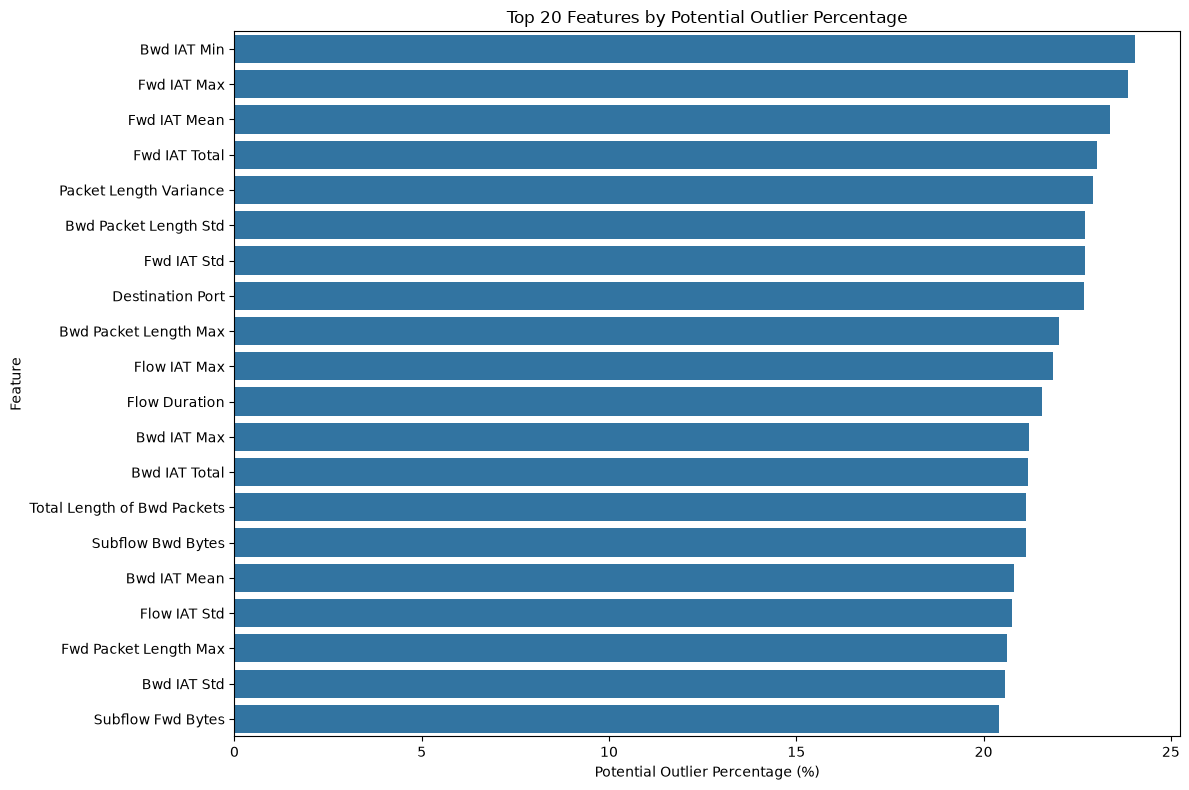

In [33]:
top_outliers = outlier_summary_df.head(20)

plt.figure(figsize=(12, 8))

sns.barplot(
    data=top_outliers,
    x="Outlier_Percentage",
    y="Feature"
)

plt.title("Top 20 Features by Potential Outlier Percentage")
plt.xlabel("Potential Outlier Percentage (%)")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

In [34]:
outlier_summary_df.head(20)

,Feature,Outlier_Count,Outlier_Percentage
29,Bwd IAT Min,268827,24.030711
23,Fwd IAT Max,266744,23.844510
21,Fwd IAT Mean,261394,23.366268
20,Fwd IAT Total,257748,23.040348
39,Packet Length Variance,256553,22.933526
13,Bwd Packet Length Std,254168,22.720329
22,Fwd IAT Std,254092,22.713535
0,Destination Port,253596,22.669197
10,Bwd Packet Length Max,246121,22.000999
18,Flow IAT Max,244418,21.848767


## 27. Split the Dataset into Training and Testing Sets

Before applying data-dependent preprocessing techniques, the dataset is divided into training and testing sets.

An **80:20 stratified train-test split** is used, where 80% of the data is allocated to the training set and 20% to the testing set. Stratification is applied using the target variable so that the class distribution is maintained as consistently as possible across both subsets.

This step is intentionally performed **before IQR-based outlier capping and correlation-based feature filtering**. The training dataset will be used to learn the parameters and preprocessing decisions, while the same learned decisions will be applied to the testing dataset.

This approach helps prevent information from the testing dataset from influencing the preprocessing process and provides a more reliable basis for evaluating the machine learning models later in the project.

### Key Points
- **Training data:** Used to learn preprocessing parameters and train machine learning models.
- **Testing data:** Kept separate for final model evaluation.
- **Split ratio:** 80% training and 20% testing.
- **Stratification:** Maintains the target-class distribution across both subsets.
- **Leakage prevention:** Data-dependent preprocessing decisions are learned from training data only.

In [35]:
# Split the dataset into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Initial train-test split completed successfully!")

print("\nTraining feature shape:", X_train.shape)
print("Testing feature shape:", X_test.shape)

print("\nTraining target shape:", y_train.shape)
print("Testing target shape:", y_test.shape)

Initial train-test split completed successfully!

Training feature shape: (894944, 68)
Testing feature shape: (223737, 68)

Training target shape: (894944,)
Testing target shape: (223737,)


## 28. Verify the Initial Training and Testing Sets

After performing the stratified train-test split, the dimensions of the training and testing datasets are verified to ensure that the data has been divided correctly.

The feature matrices and target vectors are checked independently. This verification confirms that:

- The training and testing feature matrices contain the expected number of samples.
- The training and testing target variables contain the corresponding number of labels.
- Both datasets contain the same initial set of features.
- The 80:20 split has been successfully created.
- The target variable remains separated from the feature matrices.

This verification is important before applying any further preprocessing because all subsequent data-dependent preprocessing operations will be learned from the training set and then consistently applied to the testing set.

In [36]:
# Verify the dimensions and feature consistency of the train-test split

print("TRAINING DATA")
print("-" * 40)
print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)

print("\nTESTING DATA")
print("-" * 40)
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

print("\nFEATURE CONSISTENCY")
print("-" * 40)
print("Same number of features:", X_train.shape[1] == X_test.shape[1])
print("Same feature columns:", list(X_train.columns) == list(X_test.columns))

TRAINING DATA
----------------------------------------
X_train shape: (894944, 68)
y_train shape: (894944,)

TESTING DATA
----------------------------------------
X_test shape: (223737, 68)
y_test shape: (223737,)

FEATURE CONSISTENCY
----------------------------------------
Same number of features: True
Same feature columns: True


## 29. Analyze the Training Target Distribution

The distribution of target classes within the training dataset is examined to understand the class composition used for model training.

Since the dataset represents a multi-class network intrusion detection problem, it is important to determine whether the training data contains balanced or imbalanced target classes.

Class imbalance occurs when some attack categories contain substantially fewer observations than other categories. This can influence the learning process of machine learning algorithms and may cause models to perform better on majority classes than minority classes.

The training target distribution is analyzed separately because the training dataset is the portion of the data used to learn the machine learning models.

The results obtained in this section will also be compared with the testing target distribution in the following sections to verify that stratification has maintained a similar class distribution across both datasets.

In [37]:
# Analyze the target-class distribution in the training dataset

train_target_distribution = y_train.value_counts().sort_index()

print("Training Target Class Distribution")
print("-" * 45)
print(train_target_distribution)

print("\nTraining Target Class Percentages")
print("-" * 45)
print((y_train.value_counts(normalize=True).sort_index() * 100).round(2))

Training Target Class Distribution
---------------------------------------------
Target_Encoded
0    718314
1      1562
2    102413
3     72655
Name: count, dtype: int64

Training Target Class Percentages
---------------------------------------------
Target_Encoded
0    80.26
1     0.17
2    11.44
3     8.12
Name: proportion, dtype: float64


## 30. Analyze the Testing Target Distribution

The distribution of target classes within the testing dataset is examined to understand the composition of the held-out data that will later be used for model evaluation.

The testing dataset must remain separate from model training and preprocessing decisions. Therefore, this analysis is performed only to describe and verify the class distribution; it is not used to calculate preprocessing parameters or make feature-selection decisions.

Examining the testing target distribution also allows the effect of stratified sampling to be verified. The class proportions in the testing set should be broadly consistent with those observed in the training set.

This is particularly important for the network intrusion detection problem because the dataset contains multiple traffic and attack categories, including minority classes. Maintaining representative class proportions helps ensure that the final model evaluation reflects the original dataset distribution as closely as possible.

In [38]:
# Analyze the target-class distribution in the testing dataset

test_target_distribution = y_test.value_counts().sort_index()

print("Testing Target Class Distribution")
print("-" * 45)
print(test_target_distribution)

print("\nTesting Target Class Percentages")
print("-" * 45)
print((y_test.value_counts(normalize=True).sort_index() * 100).round(2))

Testing Target Class Distribution
---------------------------------------------
Target_Encoded
0    179579
1       391
2     25603
3     18164
Name: count, dtype: int64

Testing Target Class Percentages
---------------------------------------------
Target_Encoded
0    80.26
1     0.17
2    11.44
3     8.12
Name: proportion, dtype: float64


## 31. Compare Training and Testing Target Distributions

The target-class distributions of the training and testing datasets are compared to verify the effectiveness of the stratified sampling performed during the train-test split.

The comparison focuses on the percentage representation of each target class rather than only the raw number of observations, since the training and testing datasets contain different numbers of samples.

A successful stratified split should produce similar class proportions in both subsets. This is particularly important for this network intrusion detection dataset because the target classes are highly imbalanced, with some classes occurring much less frequently than others.

This comparison is performed only as a validation step. It does not modify either dataset and does not use the testing distribution to determine any preprocessing parameters or feature-selection decisions.

In [39]:
# Compare target-class percentages between training and testing datasets

train_percentages = (
    y_train.value_counts(normalize=True)
    .sort_index()
    .mul(100)
)

test_percentages = (
    y_test.value_counts(normalize=True)
    .sort_index()
    .mul(100)
)

target_distribution_comparison = pd.DataFrame({
    "Training (%)": train_percentages.round(2),
    "Testing (%)": test_percentages.round(2)
})

target_distribution_comparison["Difference (%)"] = (
    target_distribution_comparison["Training (%)"] -
    target_distribution_comparison["Testing (%)"]
).round(2)

print("Training vs Testing Target Distribution")
print("-" * 55)

target_distribution_comparison

Training vs Testing Target Distribution
-------------------------------------------------------


,Training (%),Testing (%),Difference (%)
Target_Encoded,,,
0,80.26,80.26,0.0
1,0.17,0.17,0.0
2,11.44,11.44,0.0
3,8.12,8.12,0.0


## 32. Prepare Training Data for IQR-Based Outlier Capping

The training feature matrix is prepared for the identification and treatment of extreme numerical values using the **Interquartile Range (IQR)** method.

The IQR method identifies potential extreme observations using the first quartile (Q1), third quartile (Q3), and the interquartile range:

$$
IQR = Q3 - Q1
$$

Potential lower and upper boundaries are then defined as:

$$
Lower\ Bound = Q1 - 1.5 \times IQR
$$

$$
Upper\ Bound = Q3 + 1.5 \times IQR
$$

To prevent information leakage, these statistical boundaries will be calculated **only from the training dataset**. The testing dataset will not be used to calculate Q1, Q3, IQR, or the resulting clipping boundaries.

The original training data is preserved in a separate copy so that the effect of IQR capping can later be compared with the data before treatment.

The calculated training-based boundaries will subsequently be applied consistently to both the training and testing feature matrices.

In [40]:
# Prepare copies of the training and testing data
# before applying training-based IQR capping

X_train_before_outlier = X_train.copy()
X_test_before_outlier = X_test.copy()

print("Training and testing datasets prepared for IQR analysis.")

print("\nTraining data shape:", X_train.shape)
print("Testing data shape:", X_test.shape)

print("\nOriginal training data preserved:", X_train_before_outlier.shape)
print("Original testing data preserved:", X_test_before_outlier.shape)

Training and testing datasets prepared for IQR analysis.

Training data shape: (894944, 68)
Testing data shape: (223737, 68)

Original training data preserved: (894944, 68)
Original testing data preserved: (223737, 68)


## 33. Calculate IQR Boundaries from the Training Data

The Interquartile Range (IQR) boundaries are calculated using the training dataset only.

For each numerical feature, the first quartile (Q1) and third quartile (Q3) are calculated from the training observations. The IQR is then obtained as:

$$
IQR = Q3 - Q1
$$

The lower and upper capping boundaries are calculated using:

$$
Lower\ Bound = Q1 - 1.5 \times IQR
$$

$$
Upper\ Bound = Q3 + 1.5 \times IQR
$$

These boundaries are learned exclusively from the training data. The testing dataset is not used when calculating any of these statistical values.

The resulting boundaries are stored in a dictionary so that the exact same training-derived limits can be applied to both the training and testing datasets in the next steps.

This approach ensures that the testing data does not influence the preprocessing parameters used by the machine learning pipeline.

In [42]:
# Calculate IQR boundaries using training data only

iqr_bounds = {}

for feature in X_train.select_dtypes(include=np.number).columns:
    Q1 = X_train[feature].quantile(0.25)
    Q3 = X_train[feature].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    iqr_bounds[feature] = {
        "Q1": Q1,
        "Q3": Q3,
        "IQR": IQR,
        "Lower_Bound": lower_bound,
        "Upper_Bound": upper_bound
    }

iqr_bounds_df = pd.DataFrame(iqr_bounds).T

print("Training-based IQR boundaries calculated successfully!")
print("\nNumber of features with calculated IQR boundaries:",
      len(iqr_bounds_df))

iqr_bounds_df.head(20)

Training-based IQR boundaries calculated successfully!

Number of features with calculated IQR boundaries: 68


,Q1,Q3,IQR,Lower_Bound,Upper_Bound
Destination Port,53.000000,1.039000e+03,9.860000e+02,-1.426000e+03,2.518000e+03
Flow Duration,181.000000,2.048848e+06,2.048666e+06,-3.072819e+06,5.121847e+06
Total Fwd Packets,1.000000,4.000000e+00,3.000000e+00,-3.500000e+00,8.500000e+00
Total Backward Packets,1.000000,4.000000e+00,3.000000e+00,-3.500000e+00,8.500000e+00
Total Length of Fwd Packets,12.000000,1.230000e+02,1.110000e+02,-1.545000e+02,2.895000e+02
Total Length of Bwd Packets,6.000000,4.760000e+02,4.700000e+02,-6.990000e+02,1.181000e+03
Fwd Packet Length Max,6.000000,5.500000e+01,4.900000e+01,-6.750000e+01,1.285000e+02
Fwd Packet Length Min,0.000000,3.600000e+01,3.600000e+01,-5.400000e+01,9.000000e+01
Fwd Packet Length Mean,6.000000,4.850000e+01,4.250000e+01,-5.775000e+01,1.122500e+02
Fwd Packet Length Std,0.000000,1.443376e+01,1.443376e+01,-2.165064e+01,3.608439e+01


## 34. Apply IQR-Based Capping to the Training Dataset

The IQR boundaries calculated from the training dataset are now applied to the training feature matrix.

For each numerical feature, values below the training-derived lower bound are replaced with the lower bound, while values above the training-derived upper bound are replaced with the upper bound.

This process is known as **IQR-based outlier capping** or **winsorization**.

The capping operation does not remove observations from the dataset. Instead, extreme values are limited to the calculated boundaries while preserving the original number of samples.

Because the IQR boundaries were calculated exclusively from the training data in the previous section, the training dataset can be transformed using these learned boundaries without introducing information from the testing dataset.

The same training-derived boundaries will be applied to the testing dataset in the next section to ensure consistent preprocessing.

### Key Points
- IQR boundaries are obtained from the training dataset only.
- Extreme values are capped rather than removed.
- The number of training samples remains unchanged.
- The learned boundaries will be reused for the testing dataset.
- No statistics from the testing dataset are used during this process.

In [43]:
# Apply training-based IQR capping to the training dataset

for feature, bounds in iqr_bounds.items():
    X_train[feature] = X_train[feature].clip(
        lower=bounds["Lower_Bound"],
        upper=bounds["Upper_Bound"]
    )

print("IQR-based capping applied successfully to the training dataset!")

print("\nTraining data shape after IQR capping:", X_train.shape)

IQR-based capping applied successfully to the training dataset!

Training data shape after IQR capping: (894944, 68)


## 35. Apply the Training-Based IQR Bounds to the Testing Dataset

The same IQR capping boundaries learned from the training dataset are now applied to the testing dataset.

No new quartiles, IQR values, or capping boundaries are calculated from the testing data. Instead, each testing feature is clipped using the corresponding lower and upper bounds that were previously calculated from the training dataset.

This ensures that the testing dataset is transformed using the same preprocessing rules learned from the training data.

Applying identical training-derived boundaries to the testing data is important for preventing data leakage and maintaining consistency between the training and testing datasets.

The testing dataset remains separate from the learning process. It is only transformed using preprocessing parameters and decisions derived from the training dataset.

### Key Points
- The testing data is not used to calculate IQR boundaries.
- Training-derived lower and upper bounds are reused.
- Extreme testing values are capped using the same rules as the training data.
- The number of testing samples and features remains unchanged.
- This maintains consistency between training and testing preprocessing.

In [44]:
# Apply the training-based IQR boundaries to the testing dataset

for feature, bounds in iqr_bounds.items():
    X_test[feature] = X_test[feature].clip(
        lower=bounds["Lower_Bound"],
        upper=bounds["Upper_Bound"]
    )

print("Training-based IQR capping applied successfully to the testing dataset!")

print("\nTesting data shape after IQR capping:", X_test.shape)

Training-based IQR capping applied successfully to the testing dataset!

Testing data shape after IQR capping: (223737, 68)


## 36. Compare Training Data Before and After IQR Capping

The training feature values before and after IQR-based capping are compared to verify the effect of the outlier treatment.

The comparison is performed using the original training dataset preserved before capping and the training dataset after the training-derived IQR boundaries have been applied.

The analysis focuses on the minimum and maximum values of the numerical features. After capping, extreme values should be limited to their corresponding training-based lower and upper IQR boundaries.

The number of samples and features should remain unchanged because IQR capping modifies extreme values rather than removing observations or features.

This comparison provides a direct verification that the outlier treatment has been successfully applied to the training dataset.

In [45]:
# Compare training feature ranges before and after IQR capping

comparison = pd.DataFrame({
    "Before_Min": X_train_before_outlier.min(),
    "After_Min": X_train.min(),
    "Before_Max": X_train_before_outlier.max(),
    "After_Max": X_train.max()
})

# Calculate the amount of change in minimum and maximum values
comparison["Min_Change"] = (
    comparison["After_Min"] - comparison["Before_Min"]
)

comparison["Max_Change"] = (
    comparison["After_Max"] - comparison["Before_Max"]
)

print("Training Data: Before vs After IQR Capping")
print("-" * 70)

comparison.head(20)

Training Data: Before vs After IQR Capping
----------------------------------------------------------------------


,Before_Min,After_Min,Before_Max,After_Max,Min_Change,Max_Change
Destination Port,0.0,0.000000,6.553400e+04,2.518000e+03,0.000000e+00,-6.301600e+04
Flow Duration,-13.0,-13.000000,1.200000e+08,5.121847e+06,0.000000e+00,-1.148781e+08
Total Fwd Packets,1.0,1.000000,2.197590e+05,8.500000e+00,0.000000e+00,-2.197505e+05
Total Backward Packets,0.0,0.000000,2.919220e+05,8.500000e+00,0.000000e+00,-2.919135e+05
Total Length of Fwd Packets,0.0,0.000000,1.323378e+06,2.895000e+02,0.000000e+00,-1.323088e+06
Total Length of Bwd Packets,0.0,0.000000,6.554530e+08,1.181000e+03,0.000000e+00,-6.554518e+08
Fwd Packet Length Max,0.0,0.000000,2.482000e+04,1.285000e+02,0.000000e+00,-2.469150e+04
Fwd Packet Length Min,0.0,0.000000,2.325000e+03,9.000000e+01,0.000000e+00,-2.235000e+03
Fwd Packet Length Mean,0.0,0.000000,5.675444e+03,1.122500e+02,0.000000e+00,-5.563194e+03
Fwd Packet Length Std,0.0,0.000000,7.125597e+03,3.608439e+01,0.000000e+00,-7.089512e+03


## 37. Visualize the Effect of IQR-Based Outlier Capping

A visual comparison is performed to observe the effect of IQR-based outlier capping on selected numerical features.

Boxplots are used because they provide a clear representation of the distribution, median, quartiles, and extreme values within a feature.

The distributions before and after IQR capping are compared using the original training data preserved before capping and the training data after capping.

Only selected features are visualized to keep the analysis readable, as the dataset contains 68 numerical features.

This visualization helps demonstrate how extreme values have been restricted to the training-derived IQR boundaries while preserving the overall structure of the data.

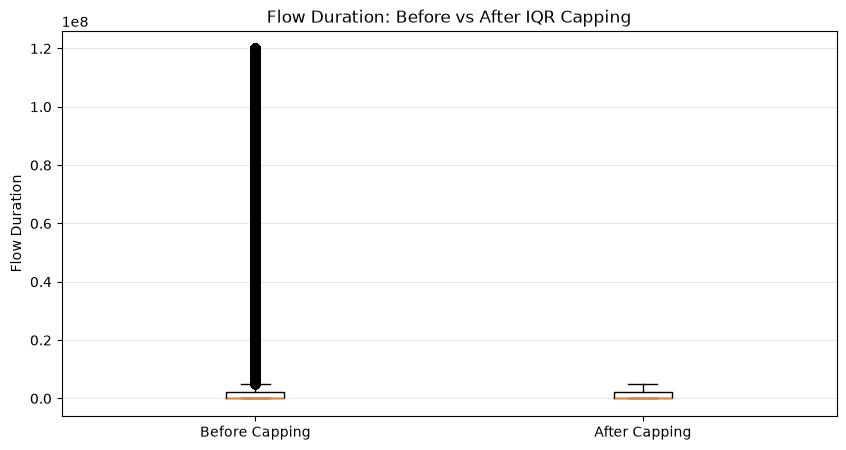

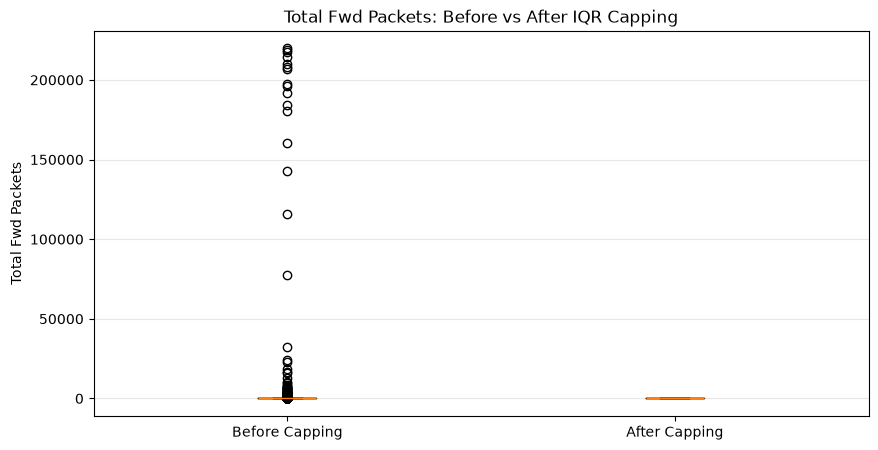

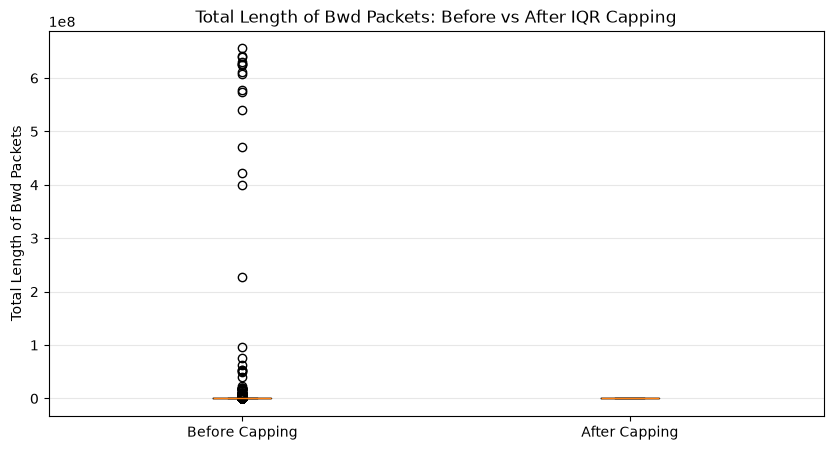

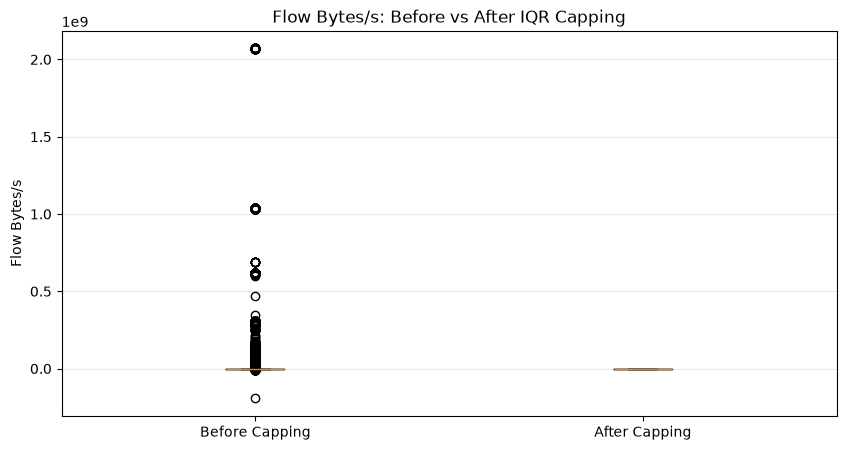

In [47]:
# Visualize selected features before and after IQR capping

import matplotlib.pyplot as plt

selected_features = [
    "Flow Duration",
    "Total Fwd Packets",
    "Total Length of Bwd Packets",
    "Flow Bytes/s"
]

for feature in selected_features:
    plt.figure(figsize=(10, 5))

    plt.boxplot(
        [
            X_train_before_outlier[feature],
            X_train[feature]
        ],
        tick_labels=["Before Capping", "After Capping"]
    )

    plt.title(f"{feature}: Before vs After IQR Capping")
    plt.ylabel(feature)
    plt.grid(axis="y", alpha=0.3)

    plt.show()

## 38. Check Remaining Extreme Values After IQR Capping

After applying IQR-based capping to both the training and testing datasets, the remaining extreme values are examined to verify that the capping operation has been applied correctly.

The minimum and maximum values of each feature are compared with the training-derived IQR boundaries calculated in Section 33.

For the training dataset, values should fall within the calculated lower and upper IQR boundaries because the training data was directly capped using these limits.

For the testing dataset, the values are also expected to remain within the same training-derived boundaries after applying the corresponding clipping rules.

This verification does not recalculate any preprocessing parameters from the testing data. The training-derived IQR boundaries remain the only reference used for validation.

The purpose of this section is to confirm that:
- IQR capping was successfully applied.
- No feature contains values outside its training-derived capping boundaries.
- The training and testing datasets retain the same number of samples and features.
- The preprocessing operation has not removed any observations.

### Key Points
- Training-derived IQR boundaries are used for verification.
- Training and testing values are checked against the same boundaries.
- No new statistical parameters are calculated from the testing data.
- Dataset dimensions remain unchanged.

In [48]:
# Check remaining extreme values after IQR capping

train_out_of_bounds = {}
test_out_of_bounds = {}

for feature, bounds in iqr_bounds.items():
    train_below = (X_train[feature] < bounds["Lower_Bound"]).sum()
    train_above = (X_train[feature] > bounds["Upper_Bound"]).sum()

    test_below = (X_test[feature] < bounds["Lower_Bound"]).sum()
    test_above = (X_test[feature] > bounds["Upper_Bound"]).sum()

    train_out_of_bounds[feature] = train_below + train_above
    test_out_of_bounds[feature] = test_below + test_above

print("Remaining Out-of-Bounds Values After IQR Capping")
print("-" * 60)

print(
    "Training out-of-bounds values:",
    sum(train_out_of_bounds.values())
)

print(
    "Testing out-of-bounds values:",
    sum(test_out_of_bounds.values())
)

print("\nTraining features with remaining out-of-bounds values:")
print(
    sum(value > 0 for value in train_out_of_bounds.values())
)

print("\nTesting features with remaining out-of-bounds values:")
print(
    sum(value > 0 for value in test_out_of_bounds.values())
)

print("\nDataset shapes")
print("-" * 60)
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)

Remaining Out-of-Bounds Values After IQR Capping
------------------------------------------------------------
Training out-of-bounds values: 0
Testing out-of-bounds values: 0

Training features with remaining out-of-bounds values:
0

Testing features with remaining out-of-bounds values:
0

Dataset shapes
------------------------------------------------------------
X_train: (894944, 68)
X_test: (223737, 68)


## 39. Calculate the Training Correlation Matrix

After completing the IQR-based outlier treatment, the relationships between the numerical features in the training dataset are analyzed using a correlation matrix.

Correlation analysis measures the strength and direction of the linear relationship between pairs of numerical features. Highly correlated features may contain similar or redundant information, which can increase the dimensionality of the dataset without providing substantial additional information.

The Pearson correlation coefficient is used to measure the linear relationship between features. Its values range from -1 to +1:

- A value close to **+1** indicates a strong positive linear relationship.
- A value close to **-1** indicates a strong negative linear relationship.
- A value close to **0** indicates little or no linear relationship.

A correlation threshold will be used in the following sections to identify highly correlated features that may be considered for removal.

To prevent information leakage, the correlation matrix is calculated **only from the training dataset**. The testing dataset is not used to determine which features should be removed.

The resulting correlation information will be used only for feature-selection decisions based on the training data. The same selected feature removals will subsequently be applied to the testing dataset.

### Key Points
- Correlation analysis is performed on training data only.
- Pearson correlation is used to measure linear relationships.
- Highly correlated features may represent redundant information.
- The testing dataset is not used to determine feature removal.
- Training-derived feature-selection decisions will later be applied consistently to the testing dataset.

In [49]:
# Calculate the correlation matrix using training data only

train_correlation_matrix = X_train.corr()

print("Training correlation matrix calculated successfully!")
print("\nCorrelation matrix shape:", train_correlation_matrix.shape)

train_correlation_matrix.head()

Training correlation matrix calculated successfully!

Correlation matrix shape: (68, 68)


,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,Bwd Packet Length Max,Bwd Packet Length Min,Bwd Packet Length Mean,Bwd Packet Length Std,Flow Bytes/s,Flow Packets/s,Flow IAT Mean,Flow IAT Std,Flow IAT Max,Flow IAT Min,Fwd IAT Total,Fwd IAT Mean,Fwd IAT Std,Fwd IAT Max,Fwd IAT Min,Bwd IAT Total,Bwd IAT Mean,Bwd IAT Std,Bwd IAT Max,Bwd IAT Min,Fwd PSH Flags,Fwd Header Length,Bwd Header Length,Fwd Packets/s,Bwd Packets/s,Min Packet Length,Max Packet Length,Packet Length Mean,Packet Length Std,Packet Length Variance,FIN Flag Count,SYN Flag Count,RST Flag Count,PSH Flag Count,ACK Flag Count,URG Flag Count,ECE Flag Count,Down/Up Ratio,Average Packet Size,Avg Fwd Segment Size,Avg Bwd Segment Size,Fwd Header Length.1,Subflow Fwd Packets,Subflow Fwd Bytes,Subflow Bwd Packets,Subflow Bwd Bytes,Init_Win_bytes_forward,Init_Win_bytes_backward,act_data_pkt_fwd,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min
Destination Port,1.000000,-0.180019,-0.248609,-0.212751,-0.247475,-0.366117,-0.267514,-0.407448,-0.298120,-0.039460,-0.377065,-0.421491,-0.422715,-0.265299,0.184652,0.631943,-0.188748,-0.174448,-0.177874,-0.065471,-0.218765,-0.207419,-0.216630,-0.214057,-0.165996,-0.148284,-0.146992,-0.141135,-0.150136,-0.346940,NaN,-0.250762,-0.238997,0.629829,0.468885,-0.440064,-0.217282,-0.305725,-0.215123,-0.185697,NaN,NaN,NaN,-0.004935,0.509500,NaN,NaN,0.025649,-0.314033,-0.298120,-0.422715,-0.250762,-0.248609,-0.247475,-0.212751,-0.366117,0.006801,0.124289,-0.267215,0.102125,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Flow Duration,-0.180019,1.000000,0.660417,0.529209,0.465079,0.406505,0.408277,-0.302023,0.242532,0.478630,0.397429,-0.322815,0.290232,0.459131,-0.402151,-0.400516,0.950803,0.974298,0.997707,-0.092126,0.922181,0.906654,0.827687,0.910736,0.351628,0.656885,0.664191,0.584372,0.657395,0.292435,NaN,0.624105,0.514236,-0.404348,-0.366302,-0.324369,0.448513,0.352604,0.430270,0.443963,NaN,NaN,NaN,0.273078,0.081449,NaN,NaN,-0.249084,0.321294,0.242532,0.290232,0.624105,0.660417,0.465079,0.529209,0.406505,0.241141,0.309199,0.622620,-0.238599,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Total Fwd Packets,-0.248609,0.660417,1.000000,0.797944,0.809065,0.737492,0.731301,-0.405888,0.484429,0.808336,0.723573,-0.352501,0.585798,0.765727,-0.304587,-0.418052,0.558342,0.631320,0.643826,-0.362243,0.718840,0.676625,0.799822,0.704794,0.277583,0.662472,0.628927,0.701267,0.638422,0.423222,NaN,0.974501,0.808277,-0.414181,-0.425097,-0.401798,0.746696,0.635973,0.726239,0.741175,NaN,NaN,NaN,0.491928,-0.114336,NaN,NaN,-0.449571,0.585547,0.484429,0.585798,0.974501,1.000000,0.809065,0.797944,0.737492,0.458715,0.386062,0.929525,-0.169829,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Total Backward Packets,-0.212751,0.529209,0.797944,1.000000,0.773052,0.842769,0.741552,-0.298770,0.530825,0.760573,0.825728,-0.250759,0.710427,0.834020,-0.253432,-0.406981,0.416891,0.498056,0.512725,-0.361628,0.480504,0.436199,0.546367,0.461275,0.265763,0.826255,0.784202,0.863178,0.808448,0.485373,NaN,0.788975,0.981130,-0.420939,-0.301695,-0.316483,0.845725,0.765250,0.827668,0.832003,NaN,NaN,NaN,0.589274,-0.320365,NaN,NaN,0.072534,0.725195,0.530825,0.710427,0.788975,0.797944,0.773052,1.000000,0.842769,0.448550,0.410986,0.749629,-0.124341,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Total Length of Fwd Packets,-0.247475,0.465079,0.809065,0.773052,1.000000,0.634259,0.966787,-0.086709,0.824156,0.863473,0.639512,-0.096031,0.507211,0.642046,-0.214554,-0.405023,0.354986,0.426432,0.447034,-0.296452,0.496850,0.459667,0.583060,0.485748,0.232310,0.587361,0.562834,0.621785,0.562329,0.434368,NaN,0.813544,0.796545,-0.408936,-0.375893,-0.112760,0.667240,0.621711,0.660165,0.667561,NaN,NaN,NaN,0.456412,-0.350486,NaN,NaN,-0.224940,0.579023,0.824156,0.507211,0.813544,0.809065,1.000000,0.773052,0.634259,0.417708,0.278840,0.752086,-0.078139,

## 40. Identify Highly Correlated Features

The training correlation matrix is examined to identify pairs of features that have a strong linear relationship with each other.

Highly correlated features may contain similar or redundant information. Removing selected redundant features can reduce the dimensionality of the dataset and simplify the learning process while retaining the most informative features.

A correlation threshold of **0.90** is used in this preprocessing stage. Feature pairs with an absolute Pearson correlation coefficient greater than 0.90 are considered highly correlated.

The absolute correlation value is used because both strong positive and strong negative relationships indicate a high degree of linear association.

Only the **training correlation matrix** calculated in Section 39 is used to identify these feature pairs. The testing dataset is not used to determine which features should be removed.

To avoid reporting the same feature pair twice, only one triangular portion of the correlation matrix is examined.

The identified highly correlated feature pairs will be reviewed before the corresponding redundant features are removed from both the training and testing datasets.

### Key Points
- Correlation analysis is based on training data only.
- Absolute Pearson correlation is used.
- Correlation threshold: **0.90**.
- Highly correlated feature pairs are identified without using testing data.
- Duplicate feature pairs are avoided during the analysis.
- Feature removal will be performed in a later section.

In [50]:
# Identify highly correlated feature pairs using training data only

correlation_threshold = 0.90

# Use only the upper triangle to avoid duplicate feature pairs
upper_triangle = train_correlation_matrix.where(
    np.triu(
        np.ones(train_correlation_matrix.shape),
        k=1
    ).astype(bool)
)

highly_correlated_pairs = []

for feature_1 in upper_triangle.columns:
    for feature_2 in upper_triangle.index:
        correlation_value = upper_triangle.loc[feature_2, feature_1]

        if pd.notna(correlation_value) and abs(correlation_value) > correlation_threshold:
            highly_correlated_pairs.append(
                {
                    "Feature 1": feature_2,
                    "Feature 2": feature_1,
                    "Correlation": correlation_value
                }
            )

highly_correlated_df = pd.DataFrame(highly_correlated_pairs)

print("Correlation threshold:", correlation_threshold)
print(
    "\nNumber of highly correlated feature pairs:",
    len(highly_correlated_df)
)

if len(highly_correlated_df) > 0:
    highly_correlated_df = highly_correlated_df.sort_values(
        by="Correlation",
        key=lambda x: x.abs(),
        ascending=False
    )

    highly_correlated_df
else:
    print("\nNo feature pairs exceeded the correlation threshold.")

Correlation threshold: 0.9

Number of highly correlated feature pairs: 77


## 41. Visualize the Training Correlation Matrix

The correlation matrix calculated from the training dataset is visualized using a heatmap.

A heatmap provides a visual representation of the pairwise Pearson correlation coefficients between the numerical features. Strong positive and negative relationships can be identified through the intensity of the displayed correlation values.

The visualization helps provide an overall understanding of the relationships among the features and supports the identification of groups of highly correlated variables.

The heatmap is generated using the training correlation matrix only. The testing dataset is not involved in this visualization or in the feature-selection decision.

Because the dataset contains 68 features, the complete correlation matrix is displayed with a sufficiently large figure size so that the feature relationships remain readable.

### Key Points
- The visualization is based on the training correlation matrix.
- Pearson correlation coefficients are displayed.
- Strong positive and negative relationships can be visually identified.
- The testing dataset is not used.
- The visualization supports the correlation-based feature-selection process.

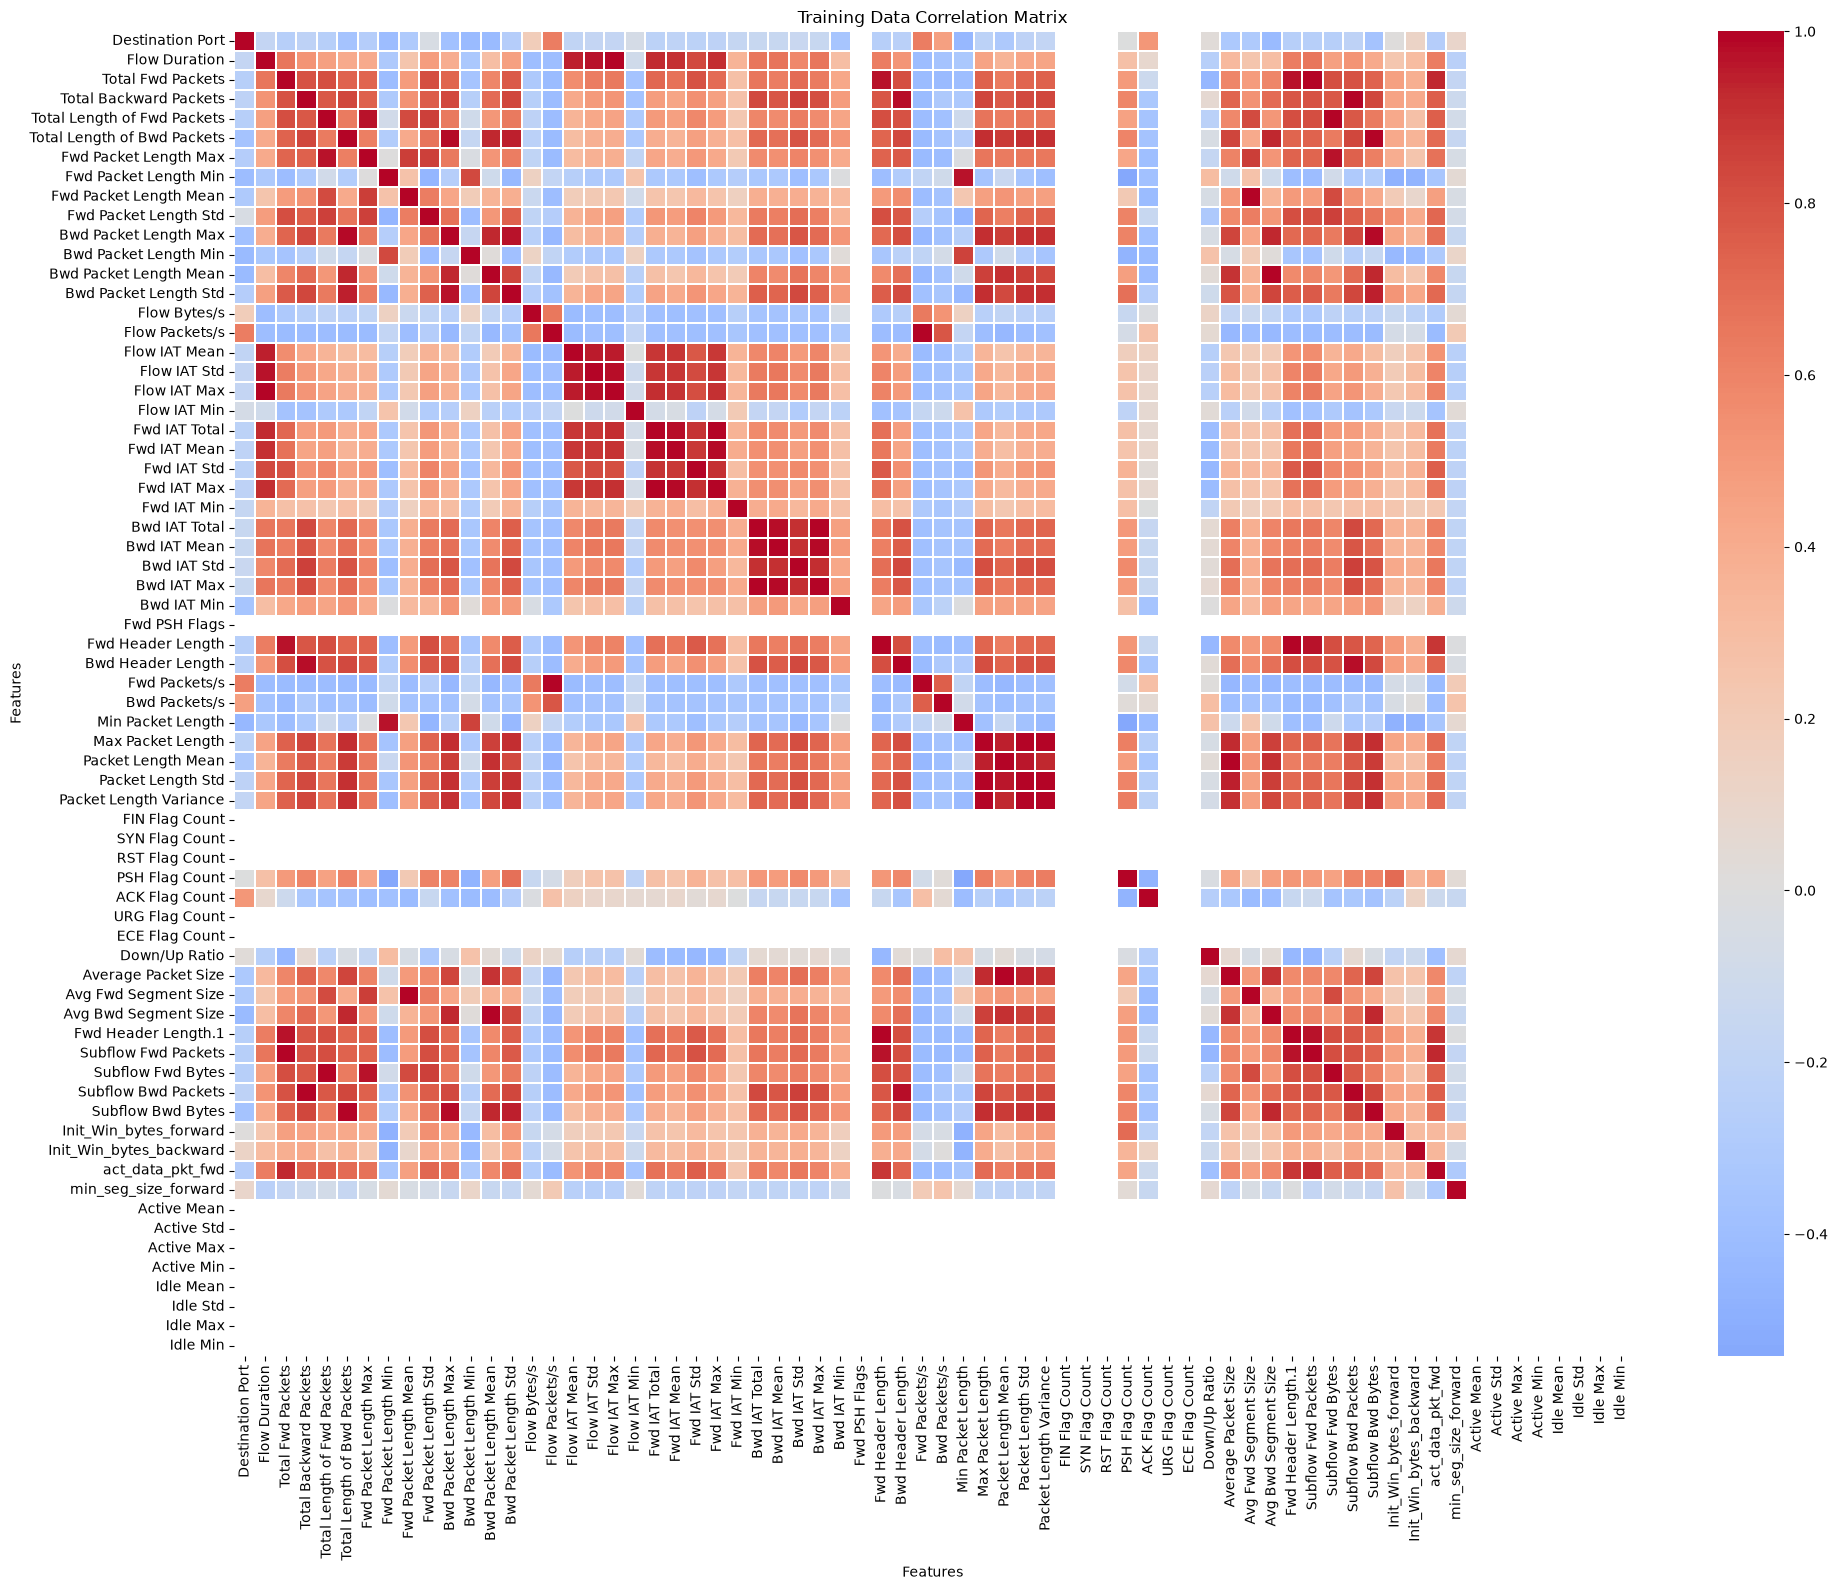

In [51]:
# Visualize the training correlation matrix

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(20, 16))

sns.heatmap(
    train_correlation_matrix,
    cmap="coolwarm",
    center=0,
    linewidths=0.1,
    cbar=True
)

plt.title("Training Data Correlation Matrix")
plt.xlabel("Features")
plt.ylabel("Features")
plt.xticks(rotation=90)
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

## 42. Remove Highly Correlated Features

The highly correlated feature pairs identified from the training correlation matrix are now used to determine which redundant features should be removed.

A correlation threshold of **0.90** is used. When two features have an absolute Pearson correlation greater than this threshold, one feature from the correlated pair is selected for removal.

The feature-selection decision is based exclusively on the training dataset. The testing dataset is not examined when determining which features should be removed.

The identified features are removed from both the training and testing feature matrices. This ensures that both datasets contain exactly the same final feature set.

Removing redundant features can reduce dimensionality and limit unnecessary duplication of information while preserving the remaining feature representation for subsequent machine learning steps.

The number of features before and after correlation-based filtering is recorded to measure the reduction achieved through this preprocessing step.

### Key Points
- Correlation threshold: **0.90**.
- Feature-removal decisions are based on training data only.
- Highly correlated features are treated as redundant candidates.
- The same features are removed from both training and testing datasets.
- The number of remaining features is recorded after filtering.

In [52]:
# Remove highly correlated features identified from training data

features_to_remove = set()

for _, row in highly_correlated_df.iterrows():
    features_to_remove.add(row["Feature 2"])

features_to_remove = sorted(features_to_remove)

print("Number of features before correlation filtering:",
      X_train.shape[1])

print("\nNumber of features identified for removal:",
      len(features_to_remove))

print("\nFeatures selected for removal:")
for feature in features_to_remove:
    print("-", feature)

# Remove the same features from training and testing datasets
X_train = X_train.drop(columns=features_to_remove)
X_test = X_test.drop(columns=features_to_remove)

print("\nCorrelation-based feature filtering completed successfully!")

print("\nTraining data shape after filtering:",
      X_train.shape)

print("Testing data shape after filtering:",
      X_test.shape)

Number of features before correlation filtering: 68

Number of features identified for removal: 31

Features selected for removal:
- Average Packet Size
- Avg Bwd Segment Size
- Avg Fwd Segment Size
- Bwd Header Length
- Bwd IAT Max
- Bwd IAT Mean
- Bwd IAT Std
- Bwd Packet Length Max
- Bwd Packet Length Mean
- Bwd Packet Length Std
- Flow IAT Max
- Flow IAT Mean
- Flow IAT Std
- Fwd Header Length
- Fwd Header Length.1
- Fwd IAT Max
- Fwd IAT Mean
- Fwd IAT Std
- Fwd IAT Total
- Fwd Packet Length Max
- Fwd Packets/s
- Max Packet Length
- Min Packet Length
- Packet Length Mean
- Packet Length Std
- Packet Length Variance
- Subflow Bwd Bytes
- Subflow Bwd Packets
- Subflow Fwd Bytes
- Subflow Fwd Packets
- act_data_pkt_fwd

Correlation-based feature filtering completed successfully!

Training data shape after filtering: (894944, 37)
Testing data shape after filtering: (223737, 37)


## 43. Verify Feature Consistency After Correlation Filtering

After removing the highly correlated features, the training and testing feature matrices are compared to verify that they contain an identical feature set.

The same features must be removed from both datasets because machine learning models require the training and testing data to have matching feature representations.

This verification checks:

- The number of remaining features in the training and testing datasets.
- Whether the feature names are identical.
- Whether the feature order is identical.
- Whether any feature exists in one dataset but not the other.

The testing dataset is not used to make any new feature-selection decisions. It is only checked to confirm consistency with the training feature set established during preprocessing.

### Key Points
- Training and testing datasets must contain the same features.
- Feature order must also remain consistent.
- No additional features are removed in this section.
- This section performs verification only.

In [53]:
# Verify feature consistency after correlation filtering

print("FEATURE CONSISTENCY CHECK")
print("-" * 50)

print("Training feature count:", X_train.shape[1])
print("Testing feature count:", X_test.shape[1])

print(
    "\nSame number of features:",
    X_train.shape[1] == X_test.shape[1]
)

print(
    "Same feature columns:",
    list(X_train.columns) == list(X_test.columns)
)

print(
    "Same feature set:",
    set(X_train.columns) == set(X_test.columns)
)

# Identify any unexpected differences
train_only_features = set(X_train.columns) - set(X_test.columns)
test_only_features = set(X_test.columns) - set(X_train.columns)

print("\nFeatures present only in training:")
print(train_only_features)

print("\nFeatures present only in testing:")
print(test_only_features)

FEATURE CONSISTENCY CHECK
--------------------------------------------------
Training feature count: 37
Testing feature count: 37

Same number of features: True
Same feature columns: True
Same feature set: True

Features present only in training:
set()

Features present only in testing:
set()


## 44. Display the Final Feature Set After Correlation Filtering

The final set of features remaining after correlation-based filtering is displayed and recorded.

The feature list represents the variables that remain available for the subsequent preprocessing and machine learning stages.

At this stage, the original 68 numerical features have been reduced to 37 features after removing redundant features whose absolute Pearson correlation exceeded the selected threshold of 0.90.

The final feature names are obtained directly from the training feature matrix. The testing dataset contains the same features in the same order, as verified in the previous section.

Recording the final feature list provides a clear reference for the feature representation used in the remaining preprocessing pipeline.

### Key Points
- Original feature count: **68**.
- Correlation threshold: **0.90**.
- Features removed through correlation filtering: **31**.
- Final feature count: **37**.
- Training and testing datasets contain the same final feature set.

In [54]:
# Display the final feature set after correlation filtering

final_features = X_train.columns.tolist()

print("FINAL FEATURE SET")
print("-" * 50)

for index, feature in enumerate(final_features, start=1):
    print(f"{index:02d}. {feature}")

print("\nTotal final features:", len(final_features))

FINAL FEATURE SET
--------------------------------------------------
01. Destination Port
02. Flow Duration
03. Total Fwd Packets
04. Total Backward Packets
05. Total Length of Fwd Packets
06. Total Length of Bwd Packets
07. Fwd Packet Length Min
08. Fwd Packet Length Mean
09. Fwd Packet Length Std
10. Bwd Packet Length Min
11. Flow Bytes/s
12. Flow Packets/s
13. Flow IAT Min
14. Fwd IAT Min
15. Bwd IAT Total
16. Bwd IAT Min
17. Fwd PSH Flags
18. Bwd Packets/s
19. FIN Flag Count
20. SYN Flag Count
21. RST Flag Count
22. PSH Flag Count
23. ACK Flag Count
24. URG Flag Count
25. ECE Flag Count
26. Down/Up Ratio
27. Init_Win_bytes_forward
28. Init_Win_bytes_backward
29. min_seg_size_forward
30. Active Mean
31. Active Std
32. Active Max
33. Active Min
34. Idle Mean
35. Idle Std
36. Idle Max
37. Idle Min

Total final features: 37


## 45. Prepare the Target Variables for Final Preprocessing

The target variables for the training and testing datasets are prepared for the remaining preprocessing steps.

The target variable represents the network traffic class that the machine learning models will learn to predict.

The target labels were encoded during the earlier preprocessing stages, resulting in four target classes represented by the encoded values **0, 1, 2, and 3**.

At this stage, the target variables are kept separate from the feature matrices. No scaling or feature transformation is applied to the target variable because the target represents categorical class labels rather than continuous numerical measurements.

The training target variable will be used during model training, while the testing target variable will remain separate for later model evaluation.

### Key Points
- Training and testing target variables remain separate.
- The target contains four encoded classes.
- Target labels are not standardized with the feature values.
- The target variable is not included in the feature matrices.
- No target-based preprocessing decisions are made in this section.

In [55]:
# Prepare and verify the target variables

print("TARGET VARIABLE VERIFICATION")
print("-" * 50)

print("Training target shape:", y_train.shape)
print("Testing target shape:", y_test.shape)

print("\nTraining target classes:")
print(sorted(y_train.unique()))

print("\nTesting target classes:")
print(sorted(y_test.unique()))

print("\nNumber of training classes:", y_train.nunique())
print("Number of testing classes:", y_test.nunique())

TARGET VARIABLE VERIFICATION
--------------------------------------------------
Training target shape: (894944,)
Testing target shape: (223737,)

Training target classes:
[np.int8(0), np.int8(1), np.int8(2), np.int8(3)]

Testing target classes:
[np.int8(0), np.int8(1), np.int8(2), np.int8(3)]

Number of training classes: 4
Number of testing classes: 4


## 46. Verify the Final Training and Testing Datasets

Before applying feature scaling, the final training and testing datasets are verified after IQR-based outlier capping and correlation-based feature filtering.

This verification confirms that the feature matrices and target vectors remain correctly aligned and that the training and testing datasets contain the expected number of observations and features.

The following properties are checked:

- Training and testing feature dimensions.
- Training and testing target dimensions.
- Number of final features.
- Matching feature names and feature order.
- Matching number of samples between each feature matrix and its corresponding target vector.
- Absence of missing values in the final feature matrices.

This section is a structural validation step only. It does not modify the data or calculate any new preprocessing parameters.

### Key Points
- Final feature count is expected to be **37**.
- Training and testing feature columns must match.
- Feature and target sample counts must remain aligned.
- Missing values are checked before scaling.
- No testing data is used to learn preprocessing parameters.

In [56]:
# Final structural verification before feature scaling

print("FINAL DATASET VERIFICATION")
print("=" * 60)

print("\nTRAINING DATA")
print("-" * 60)
print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)

print("\nTESTING DATA")
print("-" * 60)
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

print("\nFEATURE CONSISTENCY")
print("-" * 60)
print("Same feature count:", X_train.shape[1] == X_test.shape[1])
print("Same feature columns:", list(X_train.columns) == list(X_test.columns))

print("\nSAMPLE ALIGNMENT")
print("-" * 60)
print("Training samples aligned:", len(X_train) == len(y_train))
print("Testing samples aligned:", len(X_test) == len(y_test))

print("\nMISSING VALUE CHECK")
print("-" * 60)
print("Missing values in X_train:", X_train.isnull().sum().sum())
print("Missing values in X_test:", X_test.isnull().sum().sum())

print("\nFINAL FEATURE COUNT:", X_train.shape[1])

FINAL DATASET VERIFICATION

TRAINING DATA
------------------------------------------------------------
X_train shape: (894944, 37)
y_train shape: (894944,)

TESTING DATA
------------------------------------------------------------
X_test shape: (223737, 37)
y_test shape: (223737,)

FEATURE CONSISTENCY
------------------------------------------------------------
Same feature count: True
Same feature columns: True

SAMPLE ALIGNMENT
------------------------------------------------------------
Training samples aligned: True
Testing samples aligned: True

MISSING VALUE CHECK
------------------------------------------------------------
Missing values in X_train: 0
Missing values in X_test: 0

FINAL FEATURE COUNT: 37


## 47. Prepare Feature Scaling

After outlier treatment and correlation-based feature filtering, the remaining numerical features are prepared for standardization.

Feature scaling is important because the 37 retained features have different numerical ranges. For example, network-flow features such as packet counts, durations, byte rates, and flag counts can have substantially different magnitudes.

Standardization transforms each feature so that its values are centered around a mean of approximately 0 and scaled according to its standard deviation.

The scaling parameters must be learned exclusively from the training dataset. Therefore, the `StandardScaler` will be fitted using **X_train only**.

After fitting, the same scaler will be used to transform both `X_train` and `X_test`. The testing dataset will not be used to calculate the mean or standard deviation.

This approach ensures that the testing data remains independent from the parameter-learning process and prevents information leakage during preprocessing.

### Key Points
- StandardScaler is used for numerical feature standardization.
- The scaler is fitted using training data only.
- Training data is transformed using the fitted scaler.
- Testing data is transformed using the same fitted scaler.
- Testing data is not used to calculate scaling parameters.
- The target variables are not scaled.

In [57]:
# Import StandardScaler and initialize the scaler

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

print("StandardScaler initialized successfully.")
print("Number of features to be scaled:", X_train.shape[1])

StandardScaler initialized successfully.
Number of features to be scaled: 37


## 48. Fit the StandardScaler Using Training Data Only

The `StandardScaler` is fitted using the training feature matrix only.

During fitting, the scaler learns the mean and standard deviation of each of the 37 training features.

For each feature, standardization follows the general form:

$$
z = \frac{x - \mu}{\sigma}
$$

where:

- $x$ is the original feature value.
- $\mu$ is the mean calculated from the training data.
- $\sigma$ is the standard deviation calculated from the training data.
- $z$ is the resulting standardized value.

The testing dataset is deliberately excluded from the fitting process. Therefore, no statistical information from `X_test` is used to calculate the scaling parameters.

The fitted scaler will be reused in the next sections to transform both the training and testing feature matrices.

### Key Points
- `StandardScaler` is fitted using `X_train` only.
- Mean and standard deviation are learned from training data.
- `X_test` is not used during fitting.
- The fitted scaler will later transform both datasets.
- This prevents data leakage during feature scaling.

In [58]:
# Fit StandardScaler using training data only

scaler.fit(X_train)

print("StandardScaler fitted successfully!")
print("\nNumber of features fitted:", len(scaler.mean_))
print("Scaler fitted using training data only:", True)

StandardScaler fitted successfully!

Number of features fitted: 37
Scaler fitted using training data only: True


## 49. Transform the Training Data Using the Fitted StandardScaler

The training feature matrix is transformed using the `StandardScaler` fitted in the previous section.

The scaler uses the mean and standard deviation learned exclusively from `X_train` to standardize all 37 retained features.

After transformation, the training features are represented on a comparable standardized scale. Features with larger original numerical ranges no longer dominate the learning process solely because of their magnitude.

No new scaling parameters are calculated during this transformation. The already-fitted training scaler is used directly.

The target variable `y_train` remains unchanged because it represents categorical class labels rather than continuous input features.

### Key Points
- The fitted training scaler is used.
- All 37 training features are transformed.
- No new parameters are learned during transformation.
- The target variable is not transformed.
- The same fitted scaler will be used for the testing data.

In [59]:
# Transform the training feature matrix

X_train_scaled = scaler.transform(X_train)

print("Training data transformed successfully!")
print("\nScaled training data shape:", X_train_scaled.shape)
print("\nScaled training data type:", type(X_train_scaled))

Training data transformed successfully!

Scaled training data shape: (894944, 37)

Scaled training data type: <class 'numpy.ndarray'>


## 50. Transform the Testing Data Using the Fitted StandardScaler

The testing feature matrix is transformed using the `StandardScaler` that was previously fitted exclusively on the training dataset.

The same training-derived mean and standard deviation are used to transform all 37 testing features. No new scaling parameters are calculated from the testing dataset.

This ensures that the training and testing data are represented on the same standardized feature scale while keeping the testing data independent from the parameter-learning process.

The testing target variable `y_test` remains unchanged because target labels are not part of the feature-scaling process.

Using the training-fitted scaler for the testing dataset is an important step in preventing data leakage and maintaining a consistent preprocessing pipeline.

### Key Points
- The scaler fitted on `X_train` is reused.
- `X_test` is transformed using the same scaling parameters.
- No parameters are learned from `X_test`.
- All 37 testing features are transformed.
- The testing target variable is not scaled.

In [60]:
# Transform the testing feature matrix using the training-fitted scaler

X_test_scaled = scaler.transform(X_test)

print("Testing data transformed successfully!")
print("\nScaled testing data shape:", X_test_scaled.shape)
print("\nScaled testing data type:", type(X_test_scaled))

Testing data transformed successfully!

Scaled testing data shape: (223737, 37)

Scaled testing data type: <class 'numpy.ndarray'>


## 51. Convert the Scaled Data Back to DataFrames

The scaled training and testing feature matrices produced by the `StandardScaler` are NumPy arrays. To preserve the feature names and make the processed datasets easier to inspect, analyze, and save, the scaled arrays are converted back into Pandas DataFrames.

The column names are taken from the final feature set obtained after correlation-based feature filtering.

The training and testing DataFrames are created using the same feature names and in the same order. This ensures that both datasets maintain an identical feature representation after scaling.

The target variables are kept separate and are not modified during this conversion.

This step does not perform any additional transformation or scaling. It only converts the already-standardized NumPy arrays into labeled Pandas DataFrames.

### Key Points
- Scaled NumPy arrays are converted back to Pandas DataFrames.
- The 37 final feature names are restored.
- Training and testing feature order remains identical.
- No additional scaling is performed.
- Target variables remain unchanged.

In [61]:
# Convert scaled NumPy arrays back to Pandas DataFrames

X_train_scaled_df = pd.DataFrame(
    X_train_scaled,
    columns=final_features
)

X_test_scaled_df = pd.DataFrame(
    X_test_scaled,
    columns=final_features
)

print("Scaled datasets converted back to DataFrames successfully!")

print("\nScaled training DataFrame shape:", X_train_scaled_df.shape)
print("Scaled testing DataFrame shape:", X_test_scaled_df.shape)

print("\nTraining DataFrame type:", type(X_train_scaled_df))
print("Testing DataFrame type:", type(X_test_scaled_df))

print("\nFirst 5 scaled training rows:")
X_train_scaled_df.head()

Scaled datasets converted back to DataFrames successfully!

Scaled training DataFrame shape: (894944, 37)
Scaled testing DataFrame shape: (223737, 37)

Training DataFrame type: <class 'pandas.DataFrame'>
Testing DataFrame type: <class 'pandas.DataFrame'>

First 5 scaled training rows:


,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,Bwd Packet Length Min,Flow Bytes/s,Flow Packets/s,Flow IAT Min,Fwd IAT Min,Bwd IAT Total,Bwd IAT Min,Fwd PSH Flags,Bwd Packets/s,FIN Flag Count,SYN Flag Count,RST Flag Count,PSH Flag Count,ACK Flag Count,URG Flag Count,ECE Flag Count,Down/Up Ratio,Init_Win_bytes_forward,Init_Win_bytes_backward,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min
0,1.779935,-0.629664,-0.486536,-1.018954,-0.548168,-0.757377,-0.491981,-0.477611,0.584456,-0.681498,1.915528,2.293657,-0.731263,-0.634790,-0.607155,-0.774836,0.0,-0.582066,0.0,0.0,0.0,-0.710830,1.486656,0.0,0.0,-1.242116,-0.650807,-0.647157,-0.836814,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,1.779935,-0.629609,-0.865718,-0.278902,-0.897661,-0.757377,-0.773073,-1.036647,-0.634208,-0.681498,-0.649281,0.816417,-0.014038,-0.655302,-0.606777,1.697699,0.0,1.990094,0.0,0.0,0.0,-0.710830,1.486656,0.0,0.0,2.257420,-0.619496,2.344875,0.946058,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,-0.288538,1.783987,1.978149,2.126268,1.836884,1.808920,-0.773073,1.713206,1.853379,-0.681498,-0.643931,-0.636200,-0.668896,1.857450,1.818664,1.697699,0.0,-0.581904,0.0,0.0,0.0,1.406807,-0.672650,0.0,0.0,-1.242116,2.039613,0.638116,0.946058,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,-0.677311,-0.617569,-0.486536,-0.278902,-0.179784,-0.383623,1.007180,0.111643,-0.634208,0.790781,-0.582967,-0.627428,0.017146,0.349799,-0.606761,1.697699,0.0,-0.570241,0.0,0.0,0.0,-0.710830,-0.672650,0.0,0.0,0.507652,-0.655017,-0.647157,-0.836814,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,-0.650396,-0.535879,-0.107353,1.201203,-0.652071,1.808920,-0.773073,-0.774756,0.073317,-0.681498,-0.248103,-0.633749,-0.388242,-0.183520,0.991435,1.697699,0.0,-0.577490,0.0,0.0,0.0,1.406807,-0.672650,0.0,0.0,2.257420,0.422835,0.549656,-0.836814,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## 52. Verify the Scaled Training and Testing Data

After converting the standardized NumPy arrays back into Pandas DataFrames, the scaled datasets are verified to ensure that the standardization process was applied correctly.

The training data is expected to have feature means approximately equal to 0 and standard deviations approximately equal to 1 because the `StandardScaler` was fitted using the training dataset.

The testing data is transformed using the same training-fitted scaler. Therefore, its feature means and standard deviations do not necessarily have to be exactly 0 and 1 because the testing data was not used to fit the scaler.

Additional checks are performed to confirm that the scaled datasets do not contain missing or infinite values.

This verification ensures that the final feature matrices are numerically suitable for the subsequent machine learning stages.

### Key Points
- Training feature means should be approximately 0.
- Training feature standard deviations should be approximately 1.
- Testing statistics may differ because the scaler was fitted only on training data.
- Missing values are checked in both datasets.
- Infinite values are checked in both datasets.
- No additional preprocessing parameters are learned in this section.

In [62]:
# Verify the scaled training and testing datasets

print("SCALED DATA VERIFICATION")
print("=" * 60)

print("\nTRAINING DATA STATISTICS")
print("-" * 60)

train_means = X_train_scaled_df.mean()
train_stds = X_train_scaled_df.std()

print("Maximum absolute training feature mean:",
      train_means.abs().max())

print("Minimum training feature standard deviation:",
      train_stds.min())

print("Maximum training feature standard deviation:",
      train_stds.max())

print("\nTESTING DATA STATISTICS")
print("-" * 60)

test_means = X_test_scaled_df.mean()
test_stds = X_test_scaled_df.std()

print("Average absolute testing feature mean:",
      test_means.abs().mean())

print("Average testing feature standard deviation:",
      test_stds.mean())

print("\nMISSING VALUE CHECK")
print("-" * 60)

print("Missing values in X_train_scaled:",
      X_train_scaled_df.isnull().sum().sum())

print("Missing values in X_test_scaled:",
      X_test_scaled_df.isnull().sum().sum())

print("\nINFINITE VALUE CHECK")
print("-" * 60)

print("Infinite values in X_train_scaled:",
      np.isinf(X_train_scaled_df.to_numpy()).sum())

print("Infinite values in X_test_scaled:",
      np.isinf(X_test_scaled_df.to_numpy()).sum())

print("\nDATASET SHAPES")
print("-" * 60)

print("X_train_scaled:", X_train_scaled_df.shape)
print("X_test_scaled:", X_test_scaled_df.shape)

SCALED DATA VERIFICATION

TRAINING DATA STATISTICS
------------------------------------------------------------
Maximum absolute training feature mean: 1.4888191195173552e-16
Minimum training feature standard deviation: 0.0
Maximum training feature standard deviation: 1.0000005586946437

TESTING DATA STATISTICS
------------------------------------------------------------
Average absolute testing feature mean: 0.0011290154571761643
Average testing feature standard deviation: 0.6217367510406044

MISSING VALUE CHECK
------------------------------------------------------------
Missing values in X_train_scaled: 0
Missing values in X_test_scaled: 0

INFINITE VALUE CHECK
------------------------------------------------------------
Infinite values in X_train_scaled: 0
Infinite values in X_test_scaled: 0

DATASET SHAPES
------------------------------------------------------------
X_train_scaled: (894944, 37)
X_test_scaled: (223737, 37)


## 53. Final Preprocessing Validation

The complete preprocessing pipeline is validated before the processed datasets and preprocessing objects are saved.

The validation confirms that the major preprocessing stages have been completed successfully and that the resulting training and testing datasets are structurally consistent.

The following aspects are verified:

- The training and testing datasets contain the expected number of samples.
- Both datasets contain the same final 37 features.
- Training and testing target variables remain correctly aligned with their corresponding feature matrices.
- The target variables retain all four encoded classes.
- Missing values are absent from the final scaled feature matrices.
- Infinite values are absent from the final scaled feature matrices.
- The training features have been standardized using parameters learned only from the training data.
- The testing features have been transformed using the same training-fitted scaler.
- No additional preprocessing parameters are learned from the testing dataset.

The testing dataset remains completely separate from the parameter-learning process. It has only been transformed using preprocessing decisions and parameters derived from the training dataset.

This final validation provides a checkpoint before the processed datasets and fitted scaler are saved for use in the feature-selection and machine-learning stages.

In [63]:
# Final validation of the preprocessing pipeline

print("FINAL PREPROCESSING VALIDATION")
print("=" * 65)

print("\nDATASET SHAPES")
print("-" * 65)
print("X_train_scaled:", X_train_scaled_df.shape)
print("X_test_scaled :", X_test_scaled_df.shape)
print("y_train       :", y_train.shape)
print("y_test        :", y_test.shape)

print("\nFEATURE CONSISTENCY")
print("-" * 65)
print("Same feature count:",
      X_train_scaled_df.shape[1] == X_test_scaled_df.shape[1])

print("Same feature columns:",
      list(X_train_scaled_df.columns) == list(X_test_scaled_df.columns))

print("\nTARGET ALIGNMENT")
print("-" * 65)
print("Training features and target aligned:",
      len(X_train_scaled_df) == len(y_train))

print("Testing features and target aligned:",
      len(X_test_scaled_df) == len(y_test))

print("\nTARGET CLASSES")
print("-" * 65)
print("Training classes:",
      sorted(y_train.unique()))

print("Testing classes:",
      sorted(y_test.unique()))

print("\nDATA QUALITY")
print("-" * 65)
print("Missing values in training:",
      X_train_scaled_df.isnull().sum().sum())

print("Missing values in testing:",
      X_test_scaled_df.isnull().sum().sum())

print("Infinite values in training:",
      np.isinf(X_train_scaled_df.to_numpy()).sum())

print("Infinite values in testing:",
      np.isinf(X_test_scaled_df.to_numpy()).sum())

print("\nSCALING VALIDATION")
print("-" * 65)
print("Maximum absolute training mean:",
      X_train_scaled_df.mean().abs().max())

print("Maximum training standard deviation:",
      X_train_scaled_df.std().max())

print("\nFINAL FEATURE COUNT:",
      X_train_scaled_df.shape[1])

print("\nFINAL PREPROCESSING VALIDATION COMPLETED!")

FINAL PREPROCESSING VALIDATION

DATASET SHAPES
-----------------------------------------------------------------
X_train_scaled: (894944, 37)
X_test_scaled : (223737, 37)
y_train       : (894944,)
y_test        : (223737,)

FEATURE CONSISTENCY
-----------------------------------------------------------------
Same feature count: True
Same feature columns: True

TARGET ALIGNMENT
-----------------------------------------------------------------
Training features and target aligned: True
Testing features and target aligned: True

TARGET CLASSES
-----------------------------------------------------------------
Training classes: [np.int8(0), np.int8(1), np.int8(2), np.int8(3)]
Testing classes: [np.int8(0), np.int8(1), np.int8(2), np.int8(3)]

DATA QUALITY
-----------------------------------------------------------------
Missing values in training: 0
Missing values in testing: 0
Infinite values in training: 0
Infinite values in testing: 0

SCALING VALIDATION
----------------------------------

## 54. Save the Final Processed Training and Testing Datasets

The final preprocessed training and testing datasets are saved to the `data/processed/` directory for use in the subsequent feature-selection and machine-learning stages.

The saved feature matrices contain the final 37 features after IQR-based outlier capping, correlation-based feature filtering, and standardization.

The training and testing target variables are saved separately so that the feature matrices remain independent from the target labels.

The processed datasets are saved in CSV format to provide a portable and easily accessible representation of the final preprocessing output.

The feature scaling parameters are not stored in the feature CSV files. The fitted `StandardScaler` will be saved separately in the following section so that the exact preprocessing transformation can be reproduced later.

### Files Saved in This Stage

- `X_train.csv` — scaled training feature matrix.
- `X_test.csv` — scaled testing feature matrix.
- `y_train.csv` — training target labels.
- `y_test.csv` — testing target labels.

### Key Points
- Final feature count: **37**.
- Training samples: **894,944**.
- Testing samples: **223,737**.
- Training and testing features use the same feature representation.
- Target variables are saved separately.
- The fitted scaler will be saved separately.

In [64]:
# Save the final preprocessed datasets

import os

processed_dir = "../data/processed"

# Create the directory if it does not already exist
os.makedirs(processed_dir, exist_ok=True)

# Save scaled feature matrices
X_train_scaled_df.to_csv(
    os.path.join(processed_dir, "X_train.csv"),
    index=False
)

X_test_scaled_df.to_csv(
    os.path.join(processed_dir, "X_test.csv"),
    index=False
)

# Save target variables
y_train.to_csv(
    os.path.join(processed_dir, "y_train.csv"),
    index=False,
    header=["Target_Encoded"]
)

y_test.to_csv(
    os.path.join(processed_dir, "y_test.csv"),
    index=False,
    header=["Target_Encoded"]
)

print("Final preprocessed datasets saved successfully!")

print("\nSaved files:")
print("- X_train.csv")
print("- X_test.csv")
print("- y_train.csv")
print("- y_test.csv")

print("\nTraining features:", X_train_scaled_df.shape)
print("Testing features :", X_test_scaled_df.shape)
print("Training target   :", y_train.shape)
print("Testing target    :", y_test.shape)

Final preprocessed datasets saved successfully!

Saved files:
- X_train.csv
- X_test.csv
- y_train.csv
- y_test.csv

Training features: (894944, 37)
Testing features : (223737, 37)
Training target   : (894944,)
Testing target    : (223737,)


## 55. Save the Fitted StandardScaler

The fitted `StandardScaler` is saved separately so that the exact scaling parameters learned from the training dataset can be reused in later stages of the project.

The scaler contains the training-derived mean and standard deviation for each of the 37 final features.

Saving the fitted scaler allows the preprocessing transformation to be reproduced consistently without fitting a new scaler on future data.

This is particularly important when applying the trained machine learning models to new or unseen network traffic data, because new data must be transformed using the same scaling parameters that were learned during model development.

The scaler is saved using Python's `joblib` library in the `data/processed/` directory.

### Key Points
- The scaler was fitted using training data only.
- The fitted scaler contains parameters for 37 features.
- The scaler is saved separately from the CSV datasets.
- The saved scaler can be reused for future predictions.
- A new scaler should not be fitted on unseen or testing data.

In [65]:
# Save the fitted StandardScaler

import joblib
import os

scaler_path = os.path.join(
    processed_dir,
    "standard_scaler.pkl"
)

joblib.dump(
    scaler,
    scaler_path
)

print("Fitted StandardScaler saved successfully!")

print("\nSaved scaler:")
print("-", scaler_path)

print("\nNumber of features in scaler:", len(scaler.mean_))

Fitted StandardScaler saved successfully!

Saved scaler:
- ../data/processed/standard_scaler.pkl

Number of features in scaler: 37


## 56. Verify the Saved Preprocessing Files

The files generated during the final preprocessing stage are verified to ensure that the expected outputs have been successfully created in the `data/processed/` directory.

The preprocessing pipeline produces four processed CSV files containing the training and testing feature matrices and their corresponding target variables. The fitted `StandardScaler` is also stored separately as a serialized object.

This verification step checks the existence of all expected files before the preprocessing notebook is considered complete.

### Expected Files

- `X_train.csv` — final scaled training features.
- `X_test.csv` — final scaled testing features.
- `y_train.csv` — training target labels.
- `y_test.csv` — testing target labels.
- `standard_scaler.pkl` — fitted training-based StandardScaler.

### Key Points
- All required preprocessing outputs should exist.
- Processed feature matrices contain 37 final features.
- Training and testing datasets are stored separately.
- The fitted scaler is stored separately for reproducibility.

In [66]:
# Verify that all final preprocessing files exist

expected_files = [
    "X_train.csv",
    "X_test.csv",
    "y_train.csv",
    "y_test.csv",
    "standard_scaler.pkl"
]

print("SAVED PREPROCESSING FILE VERIFICATION")
print("=" * 60)

all_files_exist = True

for file_name in expected_files:
    file_path = os.path.join(processed_dir, file_name)
    exists = os.path.exists(file_path)

    print(f"{file_name}: {'FOUND' if exists else 'MISSING'}")

    if not exists:
        all_files_exist = False

print("\nAll required files available:", all_files_exist)

SAVED PREPROCESSING FILE VERIFICATION
X_train.csv: FOUND
X_test.csv: FOUND
y_train.csv: FOUND
y_test.csv: FOUND
standard_scaler.pkl: FOUND

All required files available: True


## 57. Reload and Verify the Saved Preprocessing Files

The saved preprocessing outputs are reloaded from the `data/processed/` directory to verify that the files can be successfully read and reused.

The feature matrices and target variables are loaded independently and their dimensions are compared with the final in-memory datasets created during preprocessing.

The saved `StandardScaler` is also reloaded and checked to confirm that it contains the expected number of feature parameters.

This reproducibility check ensures that the preprocessing results have been correctly stored and can be recovered for subsequent feature-selection and machine-learning stages without repeating the entire preprocessing pipeline.

### Key Points
- Saved training and testing features are reloaded.
- Saved training and testing targets are reloaded.
- Saved `StandardScaler` is reloaded.
- Dataset dimensions are verified.
- The scaler is verified to contain parameters for 37 features.
- No new preprocessing is performed during this verification.

In [67]:
# Reload and verify the saved preprocessing files

X_train_saved = pd.read_csv(
    os.path.join(processed_dir, "X_train.csv")
)

X_test_saved = pd.read_csv(
    os.path.join(processed_dir, "X_test.csv")
)

y_train_saved = pd.read_csv(
    os.path.join(processed_dir, "y_train.csv")
).squeeze()

y_test_saved = pd.read_csv(
    os.path.join(processed_dir, "y_test.csv")
).squeeze()

scaler_saved = joblib.load(
    os.path.join(processed_dir, "standard_scaler.pkl")
)

print("SAVED FILES RELOADED SUCCESSFULLY!")
print("=" * 60)

print("\nRELOADED DATASET SHAPES")
print("-" * 60)
print("X_train_saved:", X_train_saved.shape)
print("X_test_saved :", X_test_saved.shape)
print("y_train_saved:", y_train_saved.shape)
print("y_test_saved :", y_test_saved.shape)

print("\nRELOADED SCALER")
print("-" * 60)
print("Scaler type:", type(scaler_saved))
print("Number of scaler features:", len(scaler_saved.mean_))

print("\nEXPECTED DIMENSIONS")
print("-" * 60)
print("Training features correct:",
      X_train_saved.shape == (894944, 37))

print("Testing features correct:",
      X_test_saved.shape == (223737, 37))

print("Training target correct:",
      y_train_saved.shape == (894944,))

print("Testing target correct:",
      y_test_saved.shape == (223737,))

print("\nSCALER FEATURE COUNT CORRECT:",
      len(scaler_saved.mean_) == 37)

SAVED FILES RELOADED SUCCESSFULLY!

RELOADED DATASET SHAPES
------------------------------------------------------------
X_train_saved: (894944, 37)
X_test_saved : (223737, 37)
y_train_saved: (894944,)
y_test_saved : (223737,)

RELOADED SCALER
------------------------------------------------------------
Scaler type: <class 'sklearn.preprocessing._data.StandardScaler'>
Number of scaler features: 37

EXPECTED DIMENSIONS
------------------------------------------------------------
Training features correct: True
Testing features correct: True
Training target correct: True
Testing target correct: True

SCALER FEATURE COUNT CORRECT: True


## 58. Verify Saved Data Matches the Preprocessed Data

The reloaded datasets are compared with the final preprocessed datasets currently stored in memory.

This verification ensures that saving the processed data to CSV format did not alter the feature values, feature names, feature order, or target labels.

The training and testing feature matrices are compared using numerical equality checks with a small tolerance to account for floating-point representation during CSV storage and loading.

The target variables are compared directly because they contain encoded class labels.

The reloaded scaler is also verified against the original fitted scaler by comparing the learned means and scaling parameters.

A successful result confirms that the saved preprocessing outputs accurately represent the final preprocessing results and can be safely used in subsequent notebooks.

### Key Points
- Saved and in-memory feature values are compared.
- Feature names and order are verified.
- Training and testing target labels are compared.
- The saved scaler parameters are compared with the original scaler.
- No preprocessing operation is performed during this verification.

In [68]:
# Verify that saved data matches the final preprocessed data

print("SAVED DATA CONSISTENCY VERIFICATION")
print("=" * 65)

# Feature values
train_features_match = np.allclose(
    X_train_scaled_df.to_numpy(),
    X_train_saved.to_numpy(),
    rtol=1e-5,
    atol=1e-8
)

test_features_match = np.allclose(
    X_test_scaled_df.to_numpy(),
    X_test_saved.to_numpy(),
    rtol=1e-5,
    atol=1e-8
)

# Feature columns
train_columns_match = (
    list(X_train_scaled_df.columns) ==
    list(X_train_saved.columns)
)

test_columns_match = (
    list(X_test_scaled_df.columns) ==
    list(X_test_saved.columns)
)

# Target values
train_target_match = np.array_equal(
    y_train.to_numpy(),
    y_train_saved.to_numpy()
)

test_target_match = np.array_equal(
    y_test.to_numpy(),
    y_test_saved.to_numpy()
)

# Scaler parameters
scaler_mean_match = np.allclose(
    scaler.mean_,
    scaler_saved.mean_
)

scaler_scale_match = np.allclose(
    scaler.scale_,
    scaler_saved.scale_
)

print("\nFEATURE DATA")
print("-" * 65)
print("Training feature values match:", train_features_match)
print("Testing feature values match :", test_features_match)

print("\nFEATURE COLUMNS")
print("-" * 65)
print("Training columns match:", train_columns_match)
print("Testing columns match :", test_columns_match)

print("\nTARGET DATA")
print("-" * 65)
print("Training targets match:", train_target_match)
print("Testing targets match :", test_target_match)

print("\nSCALER PARAMETERS")
print("-" * 65)
print("Scaler means match:", scaler_mean_match)
print("Scaler scales match:", scaler_scale_match)

print("\nFINAL CONSISTENCY CHECK")
print("-" * 65)

all_consistent = all([
    train_features_match,
    test_features_match,
    train_columns_match,
    test_columns_match,
    train_target_match,
    test_target_match,
    scaler_mean_match,
    scaler_scale_match
])

print("All saved preprocessing outputs are consistent:", all_consistent)

SAVED DATA CONSISTENCY VERIFICATION

FEATURE DATA
-----------------------------------------------------------------
Training feature values match: True
Testing feature values match : True

FEATURE COLUMNS
-----------------------------------------------------------------
Training columns match: True
Testing columns match : True

TARGET DATA
-----------------------------------------------------------------
Training targets match: True
Testing targets match : True

SCALER PARAMETERS
-----------------------------------------------------------------
Scaler means match: True
Scaler scales match: True

FINAL CONSISTENCY CHECK
-----------------------------------------------------------------
All saved preprocessing outputs are consistent: True


## 59. Final Preprocessing Summary

The preprocessing pipeline for the CIC-IDS2017 network intrusion detection dataset has been completed successfully.

The original dataset was divided into training and testing subsets using an 80:20 stratified split. All data-dependent preprocessing operations were then performed using parameters and decisions derived exclusively from the training dataset.

The training-derived IQR boundaries were used to cap extreme values in both the training and testing datasets. Correlation analysis was subsequently performed using the training data only, and highly correlated features with an absolute Pearson correlation greater than 0.90 were removed from both datasets.

After correlation-based filtering, the feature space was reduced from 68 features to 37 features.

The remaining numerical features were standardized using `StandardScaler`. The scaler was fitted only on the training dataset and then used to transform both training and testing features.

The final processed datasets and fitted scaler were saved in the `data/processed/` directory for use in subsequent feature-selection and machine-learning stages.

### Final Preprocessing Results

| Stage | Result |
|---|---:|
| Original preprocessed features | 68 |
| Features after correlation filtering | 37 |
| Features removed | 31 |
| Training samples | 894,944 |
| Testing samples | 223,737 |
| Train-test ratio | 80:20 |
| Target classes | 4 |
| IQR threshold | 1.5 × IQR |
| Correlation threshold | 0.90 |
| Scaling method | StandardScaler |
| Missing values after preprocessing | 0 |
| Infinite values after preprocessing | 0 |

### Data Leakage Prevention

The preprocessing pipeline follows a training-only parameter-learning strategy:

1. The dataset was split into training and testing sets.
2. IQR boundaries were calculated from training data only.
3. Training-derived IQR boundaries were applied to both datasets.
4. The correlation matrix was calculated from training data only.
5. Feature-removal decisions were based on training data only.
6. The same selected feature set was applied to the testing data.
7. The StandardScaler was fitted using training data only.
8. The fitted scaler was used to transform both datasets.

This workflow prevents information from the testing dataset from influencing the preprocessing parameters or feature-selection decisions.

### Saved Outputs

The following files were generated:

- `X_train.csv`
- `X_test.csv`
- `y_train.csv`
- `y_test.csv`
- `standard_scaler.pkl`

These files provide the processed inputs required for the next stages of the project.

In [69]:
print("PREPROCESSING PIPELINE COMPLETED SUCCESSFULLY!")
print("=" * 65)

print("\nFINAL DATA")
print("-" * 65)
print("Training samples :", len(X_train_scaled_df))
print("Testing samples  :", len(X_test_scaled_df))
print("Final features   :", X_train_scaled_df.shape[1])
print("Target classes   :", y_train.nunique())

print("\nPREPROCESSING TECHNIQUES")
print("-" * 65)
print("IQR outlier capping       : Completed")
print("Correlation filtering     : Completed")
print("Feature standardization   : Completed")

print("\nDATA QUALITY")
print("-" * 65)
print("Training missing values  :",
      X_train_scaled_df.isnull().sum().sum())
print("Testing missing values   :",
      X_test_scaled_df.isnull().sum().sum())
print("Training infinite values :",
      np.isinf(X_train_scaled_df.to_numpy()).sum())
print("Testing infinite values  :",
      np.isinf(X_test_scaled_df.to_numpy()).sum())

print("\nSAVED OUTPUTS")
print("-" * 65)
for file_name in expected_files:
    print("-", file_name)

print("\n" + "=" * 65)
print("SECTION 02 PREPROCESSING COMPLETED!")
print("=" * 65)

PREPROCESSING PIPELINE COMPLETED SUCCESSFULLY!

FINAL DATA
-----------------------------------------------------------------
Training samples : 894944
Testing samples  : 223737
Final features   : 37
Target classes   : 4

PREPROCESSING TECHNIQUES
-----------------------------------------------------------------
IQR outlier capping       : Completed
Correlation filtering     : Completed
Feature standardization   : Completed

DATA QUALITY
-----------------------------------------------------------------
Training missing values  : 0
Testing missing values   : 0
Training infinite values : 0
Testing infinite values  : 0

SAVED OUTPUTS
-----------------------------------------------------------------
- X_train.csv
- X_test.csv
- y_train.csv
- y_test.csv
- standard_scaler.pkl

SECTION 02 PREPROCESSING COMPLETED!


# 35. Final Preprocessing Summary & Conclusion

## 🎯 Objective

The objective of this notebook was to perform a systematic and leakage-safe **data preprocessing pipeline** for the CIC-IDS2017 network intrusion detection dataset.

The preprocessing stage transformed the raw network-traffic data into clean, consistent, standardized training and testing datasets suitable for subsequent **feature selection and machine-learning model development**.

The complete preprocessing workflow focused on:

* Cleaning the raw dataset.
* Handling missing and invalid values.
* Separating input features and target labels.
* Encoding the target classes.
* Performing a stratified train-test split.
* Detecting and treating outliers using training-data-derived IQR boundaries.
* Removing highly correlated features using training data only.
* Standardizing the numerical features using `StandardScaler`.
* Validating the final datasets.
* Saving all processed datasets and preprocessing objects.

---

## 🔄 Complete Preprocessing Pipeline

```mermaid
flowchart TD

A["Raw CIC-IDS2017 Dataset"]

B["Initial Data Inspection<br/>Shape, Columns, Data Types"]

C["Data Cleaning<br/>Remove Invalid / Unusable Values"]

D["Separate Features and Target"]

E["Target Encoding<br/>4 Classes: 0, 1, 2, 3"]

F["Stratified Train-Test Split<br/>80% Training<br/>20% Testing"]

G["Training Data<br/>894,944 Samples × 68 Features"]

H["Testing Data<br/>223,737 Samples × 68 Features"]

I["IQR Outlier Detection<br/>Training Data Only"]

J["Apply Training-Derived IQR Bounds<br/>to Training and Testing Data"]

K["Correlation Analysis<br/>Pearson |r| ≥ 0.90<br/>Training Data Only"]

L["Remove 31 Highly Correlated Features"]

M["37 Features Remaining"]

N["StandardScaler<br/>Fit on Training Data Only"]

O["Apply Same Scaler<br/>to Training and Testing Data"]

P["Final Preprocessed Training Data<br/>894,944 × 37"]

Q["Final Preprocessed Testing Data<br/>223,737 × 37"]

R["Final Validation<br/>Missing = 0<br/>Infinite = 0<br/>Feature Consistency ✓"]

S["Save Processed Datasets"]

A --> B
B --> C
C --> D
D --> E
E --> F

F --> G
F --> H

G --> I
I --> J
H --> J

J --> K
K --> L
L --> M

M --> N
N --> O

O --> P
O --> Q

P --> R
Q --> R

R --> S
```

---

## 📊 Dataset Transformation Summary

| Preprocessing Stage         | Training Features | Testing Features |
| --------------------------- | ----------------: | ---------------: |
| After Train-Test Split      |            **68** |           **68** |
| After Correlation Filtering |            **37** |           **37** |
| Final Standardized Dataset  |            **37** |           **37** |
| Training Samples            |       **894,944** |                — |
| Testing Samples             |                 — |      **223,737** |

### 📉 Feature Reduction

```text
68 Original Preprocessed Features
              ↓
31 Highly Correlated Features Removed
              ↓
37 Final Features
```

**Features removed:** 31

**Features retained:** 37

**Dimensionality reduction:** **45.59%**

**Features retained:** **54.41%**

---

## 🧹 Data Cleaning & Quality Checks

The raw network-traffic data was systematically examined and prepared before the machine-learning stages.

The preprocessing workflow included checks for:

| Data Quality Aspect      | Result      |
| ------------------------ | ----------- |
| Missing values           | ✅ Handled   |
| Infinite values          | ✅ Handled   |
| Invalid numerical values | ✅ Addressed |
| Numerical feature types  | ✅ Verified  |
| Target labels            | ✅ Encoded   |
| Train/Test alignment     | ✅ Verified  |

The final preprocessed datasets contained **zero missing values and zero infinite values**.

---

## 🎯 Target Class Distribution

The target variable was encoded into four network-traffic classes:

| Target Class | Training Count | Training % | Testing Count | Testing % |
| -----------: | -------------: | ---------: | ------------: | --------: |
|            0 |        718,314 |     80.26% |       179,579 |    80.26% |
|            1 |          1,562 |      0.17% |           391 |     0.17% |
|            2 |        102,413 |     11.44% |        25,603 |    11.44% |
|            3 |         72,655 |      8.12% |        18,164 |     8.12% |

The dataset was split using **stratified sampling**, preserving the class distribution between the training and testing datasets.

The class-distribution comparison showed **0.00 percentage-point difference** between the training and testing proportions for all four classes.

---

## ✂️ Train-Test Split

The dataset was divided using an **80:20 stratified train-test split**.

```text
                CIC-IDS2017 Dataset
                         │
                         ▼
              Stratified 80:20 Split
                  ┌──────┴──────┐
                  ▼             ▼
             Training        Testing
             80%             20%
             894,944         223,737
             samples         samples
```

The testing dataset was kept separate so that it could later provide an unbiased evaluation of the trained machine-learning models.

---

## 📦 IQR-Based Outlier Treatment

Outlier treatment was performed using the **Interquartile Range (IQR)** method.

The IQR method identifies values outside the calculated lower and upper bounds:

```text
Q1 ─────────────── IQR ─────────────── Q3
│                                       │
Lower Bound                         Upper Bound

Q1 − 1.5 × IQR                  Q3 + 1.5 × IQR
```

The IQR boundaries were calculated using the **training data only**.

The same training-derived boundaries were then applied to both the training and testing datasets.

After treatment:

* Training out-of-bound values: **0**
* Testing out-of-bound values: **0**

This ensured consistent outlier treatment without allowing information from the testing dataset to influence the preprocessing parameters.

---

## 🔗 Correlation-Based Feature Filtering

Pearson correlation analysis was performed on the training dataset to identify redundant features.

The selected threshold was:

> **|r| ≥ 0.90**

Highly correlated features were removed to reduce redundancy and simplify the feature space.

| Correlation Stage                     |       Result |
| ------------------------------------- | -----------: |
| Features before correlation filtering |       **68** |
| Highly correlated pairs identified    | **77 pairs** |
| Features removed                      |       **31** |
| Features remaining                    |       **37** |

The correlation decisions were learned from the **training dataset only**, and the same selected feature set was applied to the testing dataset.

---

## 📏 Feature Standardization

The remaining 37 numerical features were standardized using **StandardScaler**.

```mermaid
flowchart LR

A["X_train<br/>37 Features"]
--> B["Fit StandardScaler"]

B --> C["Training Mean & Std Learned"]

C --> D["Transform X_train"]

C --> E["Transform X_test"]

D --> F["Standardized Training Data"]
E --> G["Standardized Testing Data"]
```

The scaler was **fitted only on the training dataset**.

The same fitted scaler was then used to transform the testing dataset.

This prevents information from the testing dataset from influencing the scaling parameters.

### Standardization Validation

| Validation                          |                 Result |
| ----------------------------------- | ---------------------: |
| Maximum absolute training mean      |                     ~0 |
| Minimum training standard deviation | 0 for constant feature |
| Maximum training standard deviation |                     ~1 |
| Average absolute testing mean       |               ~0.00113 |
| Average testing standard deviation  |                 ~0.622 |
| Missing values                      |                      0 |
| Infinite values                     |                      0 |

The zero standard deviation observed for a constant feature is expected because the preprocessing pipeline retained the feature after the correlation filtering stage; such a feature is handled later during feature selection.

---

## 🔐 Data Leakage Prevention

A major methodological requirement of the preprocessing pipeline was to ensure that the **testing dataset did not influence any learned preprocessing decision**.

```mermaid
flowchart LR

A["Training Data"]

A --> B["Calculate IQR Bounds"]
A --> C["Calculate Correlations"]
A --> D["Fit StandardScaler"]

B --> E["Apply IQR Treatment"]
C --> F["Select 37 Features"]
D --> G["Transform Data"]

E --> G
F --> G

H["Testing Data"]

B --> I["Apply Same IQR Bounds"]
F --> J["Apply Same 37 Features"]
D --> K["Apply Same Scaler"]

I --> L["Final Testing Data"]
J --> L
K --> L

L -.->|"Never used to learn parameters"| A
```

### 🔒 Leakage Prevention Rules

| Operation                 | Training Data |  Testing Data |
| ------------------------- | :-----------: | :-----------: |
| IQR boundary calculation  |   ✅ Learned   | ❌ Not learned |
| Correlation analysis      |   ✅ Learned   | ❌ Not learned |
| Feature removal decisions |   ✅ Learned   | ❌ Not learned |
| Scaler fitting            |   ✅ Learned   | ❌ Not learned |
| Apply transformations     |     ✅ Yes     |     ✅ Yes     |

This ensures that the testing dataset remains a genuinely **held-out dataset** for later model evaluation.

---

## ✅ Final Preprocessing Validation

The final datasets were validated after all preprocessing operations.

| Validation Check                | Result             |
| ------------------------------- | ------------------ |
| Training shape                  | **894,944 × 37**   |
| Testing shape                   | **223,737 × 37**   |
| Training target shape           | **894,944**        |
| Testing target shape            | **223,737**        |
| Train/Test feature names        | ✅ Same             |
| Train/Test feature order        | ✅ Same             |
| Missing values                  | **0**              |
| Infinite values                 | **0**              |
| Target classes                  | **4 (0, 1, 2, 3)** |
| Target distribution consistency | ✅ Passed           |
| Feature consistency             | ✅ Passed           |
| Final preprocessing validation  | **✅ PASSED**       |

---

## 📁 Final Output Files

The preprocessing stage produced the following files:

```text
data/processed/
│
├── X_train.csv
├── X_test.csv
├── y_train.csv
├── y_test.csv
└── standard_scaler.pkl
```

These files represent the finalized preprocessed data and scaling object required by the subsequent feature-selection stage.

---

## 🏁 Final Conclusion

The preprocessing stage successfully transformed the CIC-IDS2017 network intrusion detection dataset into a clean, consistent, standardized, and machine-learning-ready format.

The dataset was first cleaned and validated, followed by separation of input features and target labels. The target variable was encoded into four classes, and the data was divided into training and testing sets using an **80:20 stratified split**. This produced **894,944 training observations** and **223,737 testing observations**, while maintaining the same class proportions across both datasets.

Outlier treatment was performed using the **IQR method**, with all IQR boundaries learned exclusively from the training data. The same boundaries were subsequently applied to the testing data. Correlation analysis was then performed using the training data with an absolute Pearson correlation threshold of **0.90**. This identified **77 highly correlated feature pairs** and resulted in the removal of **31 features**, reducing the feature space from **68 to 37 features**.

The remaining features were standardized using **StandardScaler**. Importantly, the scaler was fitted only on the training data and then applied to both training and testing datasets. This maintained the independence of the held-out testing data and prevented preprocessing leakage.

The final preprocessing pipeline was thoroughly validated. The resulting training dataset contains **894,944 × 37**, while the testing dataset contains **223,737 × 37**. Both datasets contain the same feature names in the same order, have correctly aligned target labels, and contain **zero missing values and zero infinite values**.

Overall, the preprocessing stage successfully reduced the feature space by **45.59%**, while preparing a consistent and standardized dataset for the next stage of the machine-learning pipeline.

### 🏆 Final Result

```text
Raw CIC-IDS2017 Dataset
          ↓
Data Cleaning & Validation
          ↓
Target Encoding
          ↓
Stratified 80:20 Train-Test Split
          ↓
IQR Outlier Treatment
          ↓
68 Features
          ↓
Correlation Filtering (|r| ≥ 0.90)
          ↓
31 Features Removed
          ↓
37 Features Remaining
          ↓
StandardScaler
          ↓
Final Validation
          ↓
894,944 × 37 Training Data
223,737 × 37 Testing Data
          ↓
🚀 Ready for Notebook 03
```

### ✅ Notebook 02 Status

**PREPROCESSING COMPLETED SUCCESSFULLY**

**68 → 37 Features | 45.59% Dimensionality Reduction**

**Training: 894,944 × 37**

**Testing: 223,737 × 37**

### 🚀 Next Stage

**Notebook 03 — Feature Selection**
